In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import scipy
from scipy.interpolate import interp1d
from datetime import datetime
import metpy.calc as mpc
from metpy.units import units
import cartopy.crs as ccrs
from cmcrameri import cm as cmcr
import os
import glob
from netCDF4 import Dataset
import time
import functions_module as pltfnc
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import pandas as pd
from matplotlib.ticker import AutoMinorLocator
from matplotlib.ticker import FixedLocator
from matplotlib.collections import LineCollection



matplotlib.rcParams["axes.spines.right"] = False
matplotlib.rcParams["axes.spines.top"] = False
matplotlib.rcParams["axes.spines.left"] = False
matplotlib.rcParams["axes.spines.bottom"] = False


In [2]:
def convert360_180(_ds):
    """
    convert longitude from 0-360 to -180 -- 180 deg
    """
    # check if already 
    attrs = _ds['lon'].attrs
    if _ds['lon'].min() >= 0:
        with xr.set_options(keep_attrs=True): 
            _ds.coords['lon'] = (_ds['lon'] + 180) % 360 - 180
        _ds = _ds.sortby('lon')
    return _ds

def compute_rh(t,q,p):
    """
    compute rh from T[K],q[kg/kg],p[Pa]
    """
    rh=q/(0.622/(p/100)*6.112*np.exp(17.62*(t-273.15)/(243.12+t-273.15)))
    return rh

def remap_files(folder_path, string_to_match, output_file):
    # Get list of files in the folder
    os.chdir(folder_path)
    files = glob.glob(string_to_match)
    
    # Filter files based on the string_to_match
    files_to_remap = files # [file for file in files if string_to_match in file]
    
    # List to store remapped file paths
    remapped_files = []
    
    # Loop over filtered files
    for file in files_to_remap:
        input_file = os.path.join(folder_path, file)
        output_file_single = os.path.join('/scratch/a/a270082/', f"remapped_{file}")
        
        # Call cdo command to remap the file
        cdo.sellonlatbox("-30,30,75,85", input="-remapdis,r360x180 -selhour,00  "+input_file, output=output_file_single)
  #-sellevel,300,350,400,450,500,550,600,650,700,750,775,800,825,850,875,900,925,950,975,1000
#1000/975/950/925/900/875/850/825/800/775/750/700/650/600/550/500/450/400/350/300
        # Append remapped file path to the list
        remapped_files.append(output_file_single)
   
    # Concatenate remapped files into a single file
    cdo.cat(input=remapped_files, output=output_file)
    
    # Clean up: remove remapped individual files
    for file in remapped_files:
        os.remove(file)

def compute_distance(lat, lon):
    R = 6371  # km
    lat = np.deg2rad(lat.values)
    lon = np.deg2rad(lon.values)
    dlat = np.diff(lat)
    dlon = np.diff(lon)
    a = np.sin(dlat/2)**2 + np.cos(lat[:-1])*np.cos(lat[1:])*np.sin(dlon/2)**2
    d = 2 * R * np.arcsin(np.sqrt(a))
    return np.insert(np.cumsum(d), 0, 0)

def utc_decimal_hours_to_datetime64(hours, date="2022-03-13"):
    """
    Convert decimal UTC hours into numpy datetime64 values.

    Parameters
    ----------
    hours : array-like
        Decimal UTC hours (e.g. 13.5 = 13:30 UTC)
    date : str
        Base date in YYYY-MM-DD format

    Returns
    -------
    np.ndarray
        Array of datetime64[ns]
    """
    hours = np.asarray(hours)

    # Convert hours -> nanoseconds
    ns = (hours * 3600 * 1e9).astype("timedelta64[ns]")

    # Add to base date
    base = np.datetime64(date)

    return base + ns

#Definition and caculation of the specific humidity 
def relative_to_specific_humidity(pres,temp,hum):
    pres = np.array(pres)*100
    temp = np.array(temp)+273.15
    hum = np.array(hum)
    q = hum/(0.263*pres*(np.exp((17.67*(temp-273.15))/(temp-29.65)))**(-1))
    return q

def read_nya(year): #load NYA radiosondes

    sonddir=datdir+'/NYA_sondes/datasets/'

    starttimes=[]
    startlat=[]
    startlon=[]

    temperatures=[]
    pressures=[]
    humidities=[]
    prw=[]
    windspeed=[]
    winddir=[]
    uwind=[]
    vwind=[]
    theta=[]
    theta_e=[]
    spec_hum=[]
    temp=[]#6
    pres=[]#5
    hum=[]#7
    wspd=[]#8
    wdir=[]#9
    nums=0
    for Y in range(year,year+1):
        obs=np.genfromtxt(sonddir+'NYA_UAS_'+str(Y)+'.tab',skip_header=27,usecols=(2,3,4,5,6,7,8,9),dtype=(float),delimiter=('\t'))
        obs_meta=np.genfromtxt(sonddir+'NYA_UAS_'+str(Y)+'.tab',skip_header=27,usecols=(0,1),dtype=(str),delimiter=('\t'))
        s1=obs_meta[0,1]
        starttimes.append(obs_meta[0,0])
        startlat.append(obs[0,1])
        startlon.append(obs[0,2])
        if (Y > 1993): 
            temperatures.append(np.asarray(temp))
            pressures.append(np.asarray(pres)*100)
            humidities.append(np.asarray(hum))
            windspeed.append(np.asarray(wspd))
            winddir.append(np.asarray(wdir))
            uwind.append(-np.asarray(wspd)*np.sin(np.radians(np.asarray(wdir))))
            vwind.append(-np.asarray(wspd)*np.cos(np.radians(np.asarray(wdir))))
            spec_hum.append(relative_to_specific_humidity(np.asarray(pres),np.asarray(temp),np.asarray(hum)))
            theta.append(mpc.potential_temperature(np.asarray(pres)* units("hPa"),np.asarray(temp)* units("degC")))
            theta_e.append(mpc.equivalent_potential_temperature(np.asarray(pres) * units("hPa"),np.asarray(temp)* units("degC"),mpc.dewpoint_from_relative_humidity(np.asarray(temp)* units("degC"),np.asarray(hum)/100)))
            if (np.all(np.isnan(np.asarray(hum))) or np.all(np.isnan(mpc.dewpoint_from_relative_humidity(np.asarray(temp)* units("degC"),np.asarray(hum)/100)))) : 
                    prw.append(np.nan)
            else: 
                    prw.append(mpc.precipitable_water(np.asarray(pres) * units("hPa"),mpc.dewpoint_from_relative_humidity(np.asarray(temp)* units("degC"),np.asarray(hum)/100)).magnitude) 
            
            nums=nums+1
            temp=[]#6
            pres=[]#5
            hum=[]#7
            wspd=[]#8
            wdir=[]#9
        for num,sonde in enumerate(obs_meta[:,1]):
            if (sonde == s1):
                temp.append(obs[num,4])
                pres.append(obs[num,3])
                hum.append(obs[num,5])
                wspd.append(obs[num,6])
                wdir.append(obs[num,7])
            else:
                temperatures.append(np.asarray(temp))
                pressures.append(np.asarray(pres)*100)
                humidities.append(np.asarray(hum))
                windspeed.append(np.asarray(wspd))
                winddir.append(np.asarray(wdir))
                uwind.append(-np.asarray(wspd)*np.sin(np.radians(np.asarray(wdir))))
                vwind.append(-np.asarray(wspd)*np.cos(np.radians(np.asarray(wdir))))
                spec_hum.append(relative_to_specific_humidity(np.asarray(pres),np.asarray(temp),np.asarray(hum)))
                theta.append(mpc.potential_temperature(np.asarray(pres)* units("hPa"),np.asarray(temp)* units("degC")))
                theta_e.append(mpc.equivalent_potential_temperature(np.asarray(pres) * units("hPa"),np.asarray(temp)* units("degC"),mpc.dewpoint_from_relative_humidity(np.asarray(temp)* units("degC"),np.asarray(hum)/100)))
                if (np.all(np.isnan(np.asarray(hum))) or np.all(np.isnan(mpc.dewpoint_from_relative_humidity(np.asarray(temp)* units("degC"),np.asarray(hum)/100)))) : 
                    prw.append(np.nan)
                else: 
                    prw.append(mpc.precipitable_water(np.asarray(pres) * units("hPa"),mpc.dewpoint_from_relative_humidity(np.asarray(temp)* units("degC"),np.asarray(hum)/100)).magnitude) 
                nums=nums+1
                s1=obs_meta[num,1]
                starttimes.append(obs_meta[num,0])
                startlat.append(obs[num,1])
                startlon.append(obs[num,2])
                temp=[]#6
                pres=[]#5
                hum=[]#7
                wspd=[]#8
                wdir=[]#9

    #append data from final sonde
    temperatures.append(np.asarray(temp))
    pressures.append(np.asarray(pres)*100)
    humidities.append(np.asarray(hum))
    windspeed.append(np.asarray(wspd))
    winddir.append(np.asarray(wdir))
    uwind.append(-np.asarray(wspd)*np.sin(np.radians(np.asarray(wdir))))
    vwind.append(-np.asarray(wspd)*np.cos(np.radians(np.asarray(wdir))))
    spec_hum.append(relative_to_specific_humidity(np.asarray(pres),np.asarray(temp),np.asarray(hum)))
    theta.append(mpc.potential_temperature(np.asarray(pres)* units("hPa"),np.asarray(temp)* units("degC")))
    theta_e.append(mpc.equivalent_potential_temperature(np.asarray(pres) * units("hPa"),np.asarray(temp)* units("degC"),mpc.dewpoint_from_relative_humidity(np.asarray(temp)* units("degC"),np.asarray(hum)/100)))
    if (np.all(np.isnan(np.asarray(hum))) or np.all(np.isnan(mpc.dewpoint_from_relative_humidity(np.asarray(temp)* units("degC"),np.asarray(hum)/100)))) : 
        prw.append(np.nan)

    nums=nums+1        
    return(temperatures,pressures,humidities,windspeed,winddir,uwind,vwind,spec_hum,theta,theta_e)

def extract_rh(time,lat,lon,pres):
    #compute rh from ERA5 data at given time, lat, lon, pressure level
    rh=f_q.var133.sel(time=time,lat=lat,lon=lon,plev=pres,method='nearest')/(0.622/(f_t.plev.sel(plev=pres,method='nearest')/100)*6.112*np.exp(17.62*(f_t.var130.sel(time=time,lat=lat,lon=lon,plev=pres,method='nearest')-273.15)/(243.12+f_t.var130.sel(time=time,lat=lat,lon=lon,plev=pres,method='nearest')-273.15)))
    return rh


In [3]:
# define data sets
datdir='/Users/fpithan/Documents/haloac3_paper/data/'
f_tcwv=xr.open_dataset(datdir+'E5_tcwv_all.nc')
f_t=xr.open_dataset(datdir+'E5_t_all.nc')
f_q=xr.open_dataset(datdir+'E5_q_all.nc')
f_u=xr.open_dataset(datdir+'u_ERA5_1979_2023_FS.nc')
f_v=xr.open_dataset(datdir+'v_ERA5_1979_2023_FS.nc')
f_ds02=xr.open_dataset(datdir+'HALO-AC3_HALO_Dropsondes_quickgrid_20220312.nc')
f_ds03=xr.open_dataset(datdir+'HALO-AC3_HALO_Dropsondes_quickgrid_20220313.nc')
fm_t=xr.open_dataset(datdir+'ERA5_ml_FS_20220313_130.nc')
fm_q=xr.open_dataset(datdir+'ERA5_ml_FS_20220313_133.nc')
fm_u=xr.open_dataset(datdir+'ERA5_ml_FS_20220313_131.nc')
fm_v=xr.open_dataset(datdir+'ERA5_ml_FS_20220313_132.nc')
fp_u=xr.open_dataset(datdir+'ERA5_pl_FS_20220313_131.nc')
fp_v=xr.open_dataset(datdir+'ERA5_pl_FS_20220313_132.nc')
fm_ps=xr.open_dataset(datdir+'ERA5_ml_FS_20220313_134.nc')
fm_uv=xr.open_dataset(datdir+'ERA5_ml_FS_20220313_testuv.nc')
fm_psl=xr.open_dataset(datdir+'ERA5_ml_FS_20220313_151.nc')
fm_ts=xr.open_dataset(datdir+'ERA5_ml_FS_20220313_034.nc')
f_ttr=xr.open_dataset(datdir+'ERA5_20220313_179.nc')
f_w=xr.open_dataset(datdir+'ERA5_20220313_135.nc')
f_radh=xr.open_dataset(datdir+'ERA5-ml-radheat_2022-03-13_regrid.nc')
f_lnsp=xr.open_dataset(datdir+'ERA5-ml-lnsp_2022-03-13_regrid.nc') 
f_dsall=xr.open_dataset(datdir+'merged_HALO_P5_beta_v2.nc')

mt1_time=np.loadtxt(datdir+'HALO_220313a_mastertracks.tab',delimiter='\t',skiprows=21,usecols=0,dtype='datetime64[ns]')
mt1=np.loadtxt(datdir+'HALO_220313a_mastertracks.tab',delimiter='\t',skiprows=21,usecols=[1,2,3])

ftb=xr.open_dataset(datdir+'HALO-AC3_HALO_KT19_BT_20220313_RF03_v1.0.nc')
ftb2=xr.open_dataset(datdir+'HALO-AC3_HALO_KT19_BT_20220314_RF04_v1.0.nc')

fi3=xr.open_dataset(datdir+'asi-AMSR2-n6250-20220313-v5.4.nc')

fcer=xr.open_dataset(datdir+'CERES_SYN1deg-1H_Terra-Aqua-NOAA20_Ed4.2_Subset_20220301-20220331.nc')

fz=xr.open_dataset(datdir+'/ERA5_20220313_129.nc')

dsv = xr.open_dataset(datdir+'HALO-AC3_HALO_VARCLOUD_L2B_V1_RF03_A20220313_083500_163000_P202603021751.nc')
dsv=dsv.assign_coords(time=dsv.Time)

ds = xr.open_dataset(datdir+'HALO-AC3_HALO_MIRA_L2A_RF03_A20220313_083500_163000_P202603021722_V1_0.nc')

f_bsr=xr.open_dataset(datdir+'HALO-DB_dataset9684_release1_HALOAC3_HALO_WALES_bsrgl_20220313_RF03_V20.nc')

f_iwv_obs=xr.open_dataset(datdir+'HALO-AC3_HALO_HAMP_radiometer_l2_iwv_v00_RF03_20220313.nc')
f_lwp_hamp=xr.open_dataset(datdir+'HALO-AC3_HALO_HAMP_radiometer_l2_lwp_v00_RF03_20220313.nc')

#radiation data Ehrlich

f_rad=xr.open_dataset(datdir+'REB_WAI_20220313_RF3.nc')
f_rad['time'] = utc_decimal_hours_to_datetime64(f_rad.Time.values, date="2022-03-13") # adjust time coordinate to match other datasets
f_rad.assign_coords(time=f_rad.time)

#precipitation data from radar Dorff

f_precip=xr.open_dataset(datdir+'Radar_data_RF03_with_precip.nc')

#WALES DATA 
nc_file = datdir+"/HALO-AC3_HALO_WALES_wv_20220313_RF03_V2.0_for_Pithan_etal.nc"

nc = Dataset(nc_file, mode="r")

In [4]:
#convert longitudes for seamless plotting
f_tcwv=convert360_180(f_tcwv)
f_ttr=convert360_180(f_ttr)
f_w=convert360_180(f_w)
f_t=convert360_180(f_t)
f_q=convert360_180(f_q)
fm_psl=convert360_180(fm_psl)


In [5]:
# read in NYA radiosondes for 2022
temperatures,pressures,humidities,windspeed,winddir,uwind,vwind,spec_hum,theta,theta_e=read_nya(2022)

/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/metpy/calc/thermo.py:1753: RuntimeWarning: divide by zero encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)
/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/metpy/calc/thermo.py:1754: RuntimeWarning: invalid value encountered in divide
  return mpconsts.nounit.zero_degc + 243.5 * val / (17.67 - val)
/var/folders/1s/m71688rd2kld26r435x91kbr76hw4s/T/ipykernel_28670/2778924033.py:165: UserWarning: Relative humidity >120%, ensure proper units.
  theta_e.append(mpc.equivalent_potential_temperature(np.asarray(pres) * units("hPa"),np.asarray(temp)* units("degC"),mpc.dewpoint_from_relative_humidity(np.asarray(temp)* units("degC"),np.asarray(hum)/100)))
/var/folders/1s/m71688rd2kld26r435x91kbr76hw4s/T/ipykernel_28670/2778924033.py:166: UserWarning: Relative humidity >120%, ensure proper units.
  if (np.all(np.isnan(np.asarray(hum))) or np.all(np.isnan(mpc.dewp

In [6]:
#read in flight sections (based on WALES plots from Georgios)


# =====================
# Load NetCDF above in file specifications
# =====================


# =====================
# Read coordinates
# =====================
w_time_s = nc.variables["time"][:]
w_alt    = nc.variables["altitude"][:]
w_lat    = nc.variables["latitude"][:]
w_lon    = nc.variables["longitude"][:]

# =====================
# Read data
# =====================
wvmr        = nc.variables["wvmr"][:]
q           = nc.variables["specific_humidity"][:]
q_anom      = nc.variables["specific_humidity_anomaly"][:]
q_anom_rel  = nc.variables["specific_humidity_relative_anomaly"][:]

# =====================
# Metadata
# =====================
file_name = nc.source_file
full_date = time.strptime(nc.flight_date, "%Y-%m-%dT%H:%M:%SZ")
# =====================
# Segmentation
# =====================
section_start = nc.variables["section_start_idx"][:]
section_end   = nc.variables["section_end_idx"][:]

nc.close()

#%%
"""
Calculations and products
"""
#Reconstruct Sections Dict
sections = {}

for i, (s, e) in enumerate(zip(section_start, section_end)):
    sections[f"section_{i}"] = {
        "start_idx": int(s),
        "end_idx": int(e),
        "values": w_lon[int(s):int(e)+1]
    }
    
#Parameters for map plots
wvmr_integrated = np.nansum(wvmr, axis = 1)
col_mean_q = np.nanmean(q, axis=1)
col_mean_q_anom = np.nanmean(q_anom, axis=1)
col_max_q = np.nanmax(q, axis=1)



/var/folders/1s/m71688rd2kld26r435x91kbr76hw4s/T/ipykernel_28670/3907893159.py:54: RuntimeWarning: Mean of empty slice
  col_mean_q = np.nanmean(q, axis=1)
/var/folders/1s/m71688rd2kld26r435x91kbr76hw4s/T/ipykernel_28670/3907893159.py:55: RuntimeWarning: Mean of empty slice
  col_mean_q_anom = np.nanmean(q_anom, axis=1)
/var/folders/1s/m71688rd2kld26r435x91kbr76hw4s/T/ipykernel_28670/3907893159.py:56: RuntimeWarning: All-NaN axis encountered
  col_max_q = np.nanmax(q, axis=1)


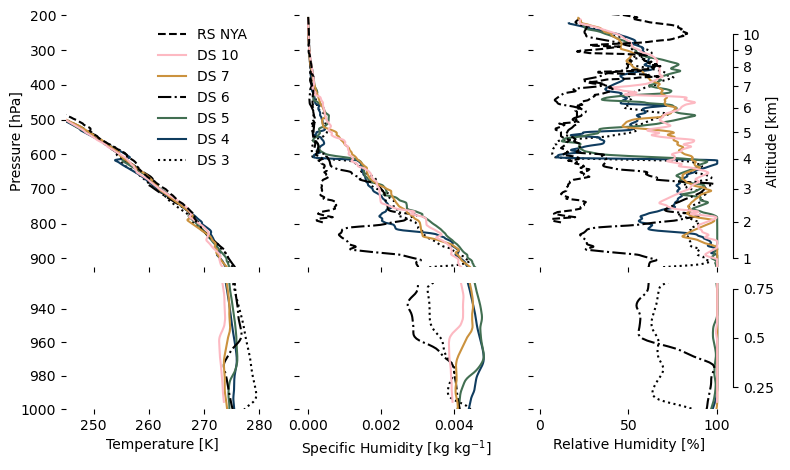

In [7]:
#plot dropsonde profiles of T, q, rh and Theta, highlighting selected dropsondes
w, h = matplotlib.figure.figaspect(0.6)
fig,axes=plt.subplots(2,3,sharey='row',sharex='col',figsize=(w,h),gridspec_kw={"height_ratios": [2, 1]})
lines=[]

#for nds in [3,4,5,6,7,8,9,10,11,12,13]: 
 #   axes[0,0].plot(f_ds03.T[nds,:],f_ds03.pres[nds,:],color='grey',linewidth=0.3)
 #   axes[0,1].plot(f_ds03.q[nds,:],f_ds03.pres[nds,:],color='grey',linewidth=0.3)
 #   axes[0,2].plot(f_ds03.rh[nds,:],f_ds03.pres[nds,:],color='grey',linewidth=0.3)

 #   axes[1,0].plot(f_ds03.T[nds,:],f_ds03.pres[nds,:],color='grey',linewidth=0.3)
 #   axes[1,1].plot(f_ds03.q[nds,:],f_ds03.pres[nds,:],color='grey',linewidth=0.3)
 #   axes[1,2].plot(f_ds03.rh[nds,:],f_ds03.pres[nds,:],color='grey',linewidth=0.3)
  #  axes[1,0].plot(f_ds03.theta[nds,:],f_ds03.pres[nds,:],color='grey',linewidth=0.3)


#select soundings for plotting and define colors and linestyle
sound_num=[3,4,5,6,7,10]
sound_style={3:'dotted',4:'solid',5:'solid',6:'dashdot',7:'solid',10:'solid'}
sound_col={3:'black',4:cmcr.batlow(0.1),5:cmcr.batlow(0.35),6:'black',7:cmcr.batlow(0.65),10:cmcr.batlow(0.9)}

for nds in sound_num: 
    l,=axes[0,0].plot(f_ds03.T[nds,:],f_ds03.pres[nds,:],color=sound_col[nds],linestyle=sound_style[nds],label='DS '+str(nds),linewidth=1.5)
    axes[0,1].plot(f_ds03.q[nds,:],f_ds03.pres[nds,:],color=sound_col[nds],linestyle=sound_style[nds],linewidth=1.5)
    axes[0,2].plot(f_ds03.rh[nds,:],f_ds03.pres[nds,:],color=sound_col[nds],linestyle=sound_style[nds],linewidth=1.5)
    axes[1,0].plot(f_ds03.T[nds,:],f_ds03.pres[nds,:],color=sound_col[nds],linestyle=sound_style[nds],linewidth=1.5)
    axes[1,1].plot(f_ds03.q[nds,:],f_ds03.pres[nds,:],color=sound_col[nds],linestyle=sound_style[nds],linewidth=1.5)
    axes[1,2].plot(f_ds03.rh[nds,:],f_ds03.pres[nds,:],color=sound_col[nds],linestyle=sound_style[nds],linewidth=1.5)
 #   ax4.plot(f_ds03.theta[nds,:],f_ds03.pres[nds,:],color=sound_col[nds],linestyle=sound_style[nds])
    lines.append(l)

#plot NYA radiosonde profiles, radiosonde 71 in the dataset, launched on 2022-03-13, which is closest in time to the dropsondes
selnya=(pressures[71] < 80000)
  
l,=axes[0,0].plot(temperatures[71][selnya]+273.15,pressures[71][selnya]/100,color='black',linestyle='dashed',label='RS NYA')
axes[0,1].plot(spec_hum[71][selnya],pressures[71][selnya]/100,color='black',linestyle='dashed')
axes[0,2].plot(humidities[71][selnya],pressures[71][selnya]/100,color='black',linestyle='dashed')
#axes[1,0].plot(theta[71].to(units.K),pressures[71]/100,color='black',linestyle='dashed')
lines.append(l)



axes[1,0].set_xlabel('Temperature [K]')
axes[0,0].set_ylabel('Pressure [hPa]')

axes[0,0].set_xlim(245,280)
axes[0,0].invert_yaxis()

axes[0,0].set_ylim(925,200)

axes[1,0].set_ylim(1000,925)

#add altitude ticks on the right y-axis

ax3b=axes[0,2].twinx()

pressure_ticks = [1,2,3,4,5,6,7,8,9,10]
altitude_ticks = np.interp(pressure_ticks,f_ds03.alt.where(f_ds03.pres[0,:]<=(925))/1000, f_ds03.pres[0,:].where(f_ds03.pres[0,:]<=(925)))

ax3b.set_ylim(axes[0,2].get_ylim())
ax3b.set_yticks(altitude_ticks)
ax3b.set_yticklabels(pressure_ticks)


ax3b.set_ylabel('Altitude [km]')
ax3b.spines["right"].set_position(("outward", 5))  # shift
ax3b.spines["right"].set_visible(True)
ax3b.spines["right"].set_bounds(altitude_ticks[0],altitude_ticks[-1])

ax4b=axes[1,2].twinx()

pressure_ticks = [0.25,0.5,0.75]
altitude_ticks = np.interp(pressure_ticks,f_ds03.alt.where(f_ds03.pres[0,:]>(925))/1000, f_ds03.pres[0,:].where(f_ds03.pres[0,:]>(925)))

ax4b.set_ylim(axes[1,2].get_ylim())
ax4b.set_yticks(altitude_ticks)
ax4b.set_yticklabels(pressure_ticks)

#ax4b.set_ylabel('Altitude [km]')
ax4b.spines["right"].set_position(("outward", 5))  # shift
ax4b.spines["right"].set_visible(True)
ax4b.spines["right"].set_bounds(altitude_ticks[0],altitude_ticks[-1])

axes[1,1].set_xlabel('Specific Humidity [kg kg$^{-1}$]')

axes[1,2].set_xlabel('Relative Humidity [%]')
    
#ax4.set_xlabel('Potential Temperature [K]')
#ax4.set_xlim(273,295)

axes[0,0].legend(handles=lines[::-1],frameon=False)
fig.tight_layout()
plt.savefig('/Users/fpithan/Documents/haloac3_paper/hac3_dsprofiles_f1b.pdf')

/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/fpithan/.local/share/mamba/envs/m

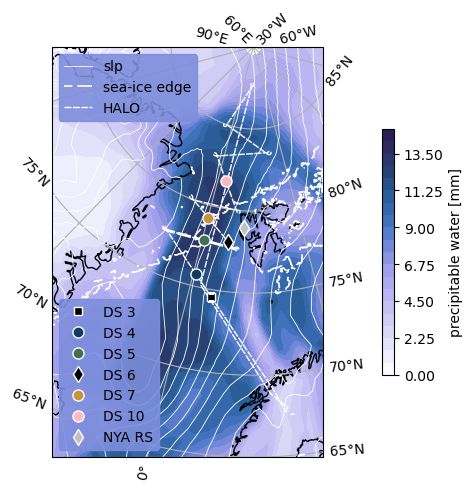

In [8]:
#plot dropsonde locations and flight track over map of ERA5 precipitable water
#define Figure
w,h=plt.figaspect(1)
fig=plt.figure(figsize=(w,h),constrained_layout=True)

handles=[]

#define map of Fram strait
ax = plt.axes(projection=ccrs.TransverseMercator(central_longitude=15.0, central_latitude=75.0, false_easting=0.0, false_northing=0.0, scale_factor=1.0, globe=None, approx=None))
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)


stime='2022-03-13 10:00:00'

#plot precipitable water and sea-level pressure contours from ERA5
cm=ax.contourf(f_tcwv.lon,f_tcwv.lat,f_tcwv.var137.sel(time=stime,method='nearest'),transform=ccrs.PlateCarree(),levels=np.linspace(0,15,21),cmap=cmcr.devon_r)

cmp=ax.contour(fm_psl.lon,fm_psl.lat,fm_psl.var151.sel(time=stime,method='nearest'),transform=ccrs.PlateCarree(),levels=np.linspace(96000,104000,33),colors='white',linewidths=0.6)

pressure_handle = Line2D([0], [0], color='white',linewidth=0.6,label='slp')
handles.append(pressure_handle)

#plot sea ice contour(s)
cmi=ax.contour(fi3.x,fi3.y,fi3.z,transform=ccrs.Stereographic(central_latitude=90.0, central_longitude=-45.0, false_easting=0.0, false_northing=0.0, true_scale_latitude=70, globe=None),levels=np.asarray([80]),colors='white',linestyles=[(5,(10,3))],linewidths=1.2)

sea_ice_handle = Line2D([0], [0], color='white',linestyle=(5,(10, 3)),linewidth=1.2,label='sea-ice edge')
handles.append(sea_ice_handle)


# plot HALO flight track 
h,=ax.plot(mt1[:,1],mt1[:,0],color='white',linewidth=1,linestyle=(0,(5,1)),transform=ccrs.PlateCarree(),label='HALO')
handles.append(h)

# Slice the sections

sec_name='section_1'

sec_info = sections[sec_name]

start_idx = sec_info['start_idx']
end_idx = sec_info['end_idx']

lat_section = w_lat[start_idx:end_idx+1]
lon_section = w_lon[start_idx:end_idx+1]

ax.plot(lon_section,lat_section,color='white',linewidth=2,linestyle=(0,(5,1)),transform=ccrs.PlateCarree(),label='section 1')


#ax.plot(lon_section,lat_section,color='white',linewidth=2,transform=ccrs.PlateCarree())


#plot dropsonde locations 
#h,=ax.plot(f_ds03.reference_lon[[3,4,5,6,7,8,9,10,11,12,13]],f_ds03.reference_lat[[3,4,5,6,7,8,9,10,11,12,13]],'+',ls='None',transform=ccrs.PlateCarree(),color='white',label='dropsondes')
#handles.append(h)
h,=ax.plot(f_ds03.reference_lon[6],f_ds03.reference_lat[6],color=sound_col[6],markersize=8,marker='d',ls='None',transform=ccrs.PlateCarree(),markeredgecolor='white',label='DS 6')
handles.append(h)

h,=ax.plot(f_ds03.reference_lon[3],f_ds03.reference_lat[3],color=sound_col[3],markersize=6,marker='s',ls='None',transform=ccrs.PlateCarree(),markeredgecolor='white',label='DS 3')
handles.append(h)

 
for ns in [4,5,7,10]:
    h,=ax.plot(f_ds03.reference_lon[ns],f_ds03.reference_lat[ns],color=sound_col[ns],markersize=8,marker='o',ls='None',transform=ccrs.PlateCarree(),markeredgecolor='white',label='DS '+str(ns))
    handles.append(h)

cbar=plt.colorbar(cm,ax=ax,pad=0.05,shrink=0.6)

#plot NYA location
nya_lon=11.922222
nya_lat=78.925
h,=ax.plot(nya_lon,nya_lat,color='silver',marker='d',markersize=8,ls='None',transform=ccrs.PlateCarree(),markeredgecolor='white',label='NYA RS')
handles.append(h)


#plot settings
cbar.set_label('precipitable water [mm]')
ax.set_extent([-15, 25, 65, 90], crs=ccrs.PlateCarree())
#ax.set_title('ERA5 precipitable water on '+stime,pad=20)
ax.coastlines()

l1=plt.legend(handles=handles[0:3],loc='upper left',frameon=True,edgecolor=cmcr.devon_r(0.5),facecolor=cmcr.devon_r(0.5),framealpha=0.9,fontsize=10)
plt.legend(handles=[handles[i] for i in [4,5,6,3,7,8,9]],loc='lower left',frameon=True,edgecolor=cmcr.devon_r(0.5),facecolor=cmcr.devon_r(0.5),framealpha=0.9,fontsize=10)

ax.add_artist(l1)
plt.savefig('/Users/fpithan/Documents/haloac3_paper/hac3_sondes_pw_220313_12_f2.pdf')

/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/fpithan/.local/share/mamba/envs/m

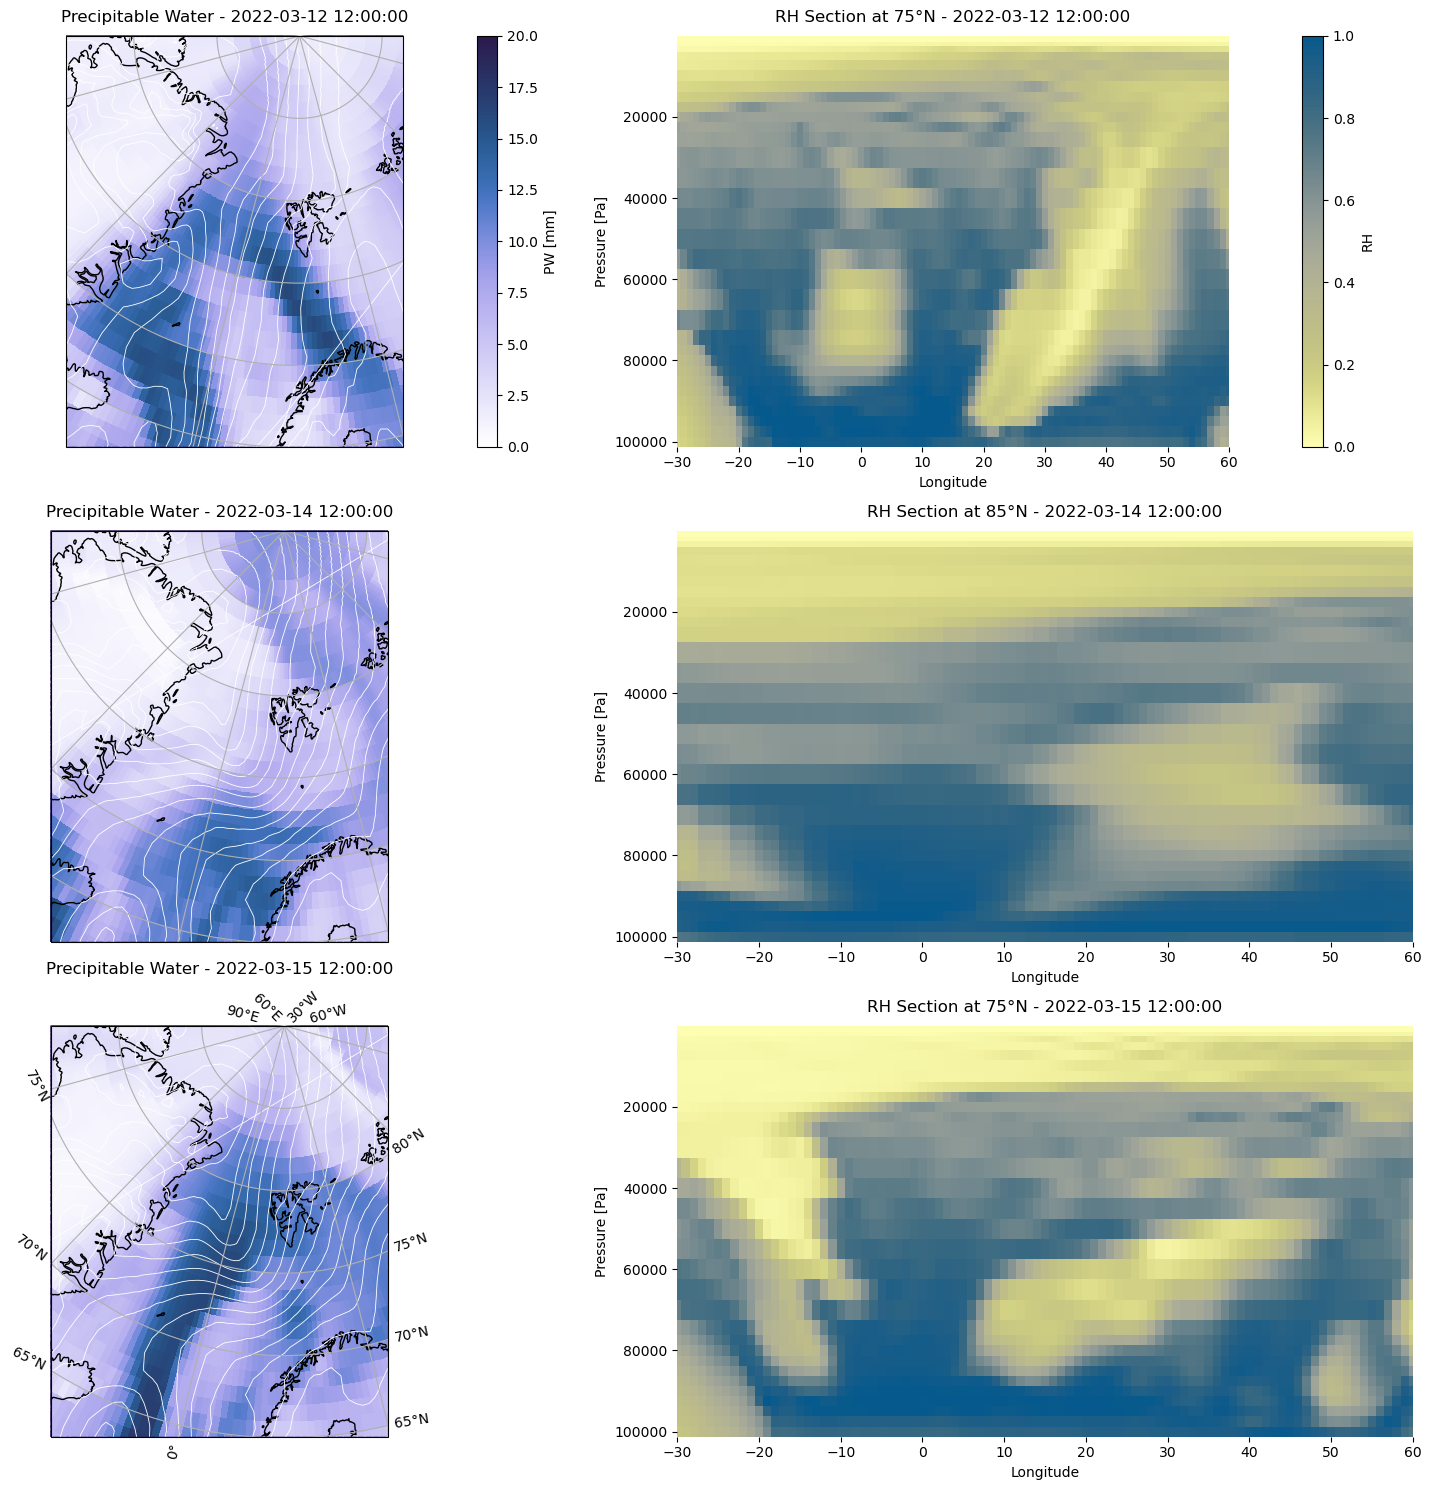

In [9]:
# Create multipanel plot: precipitable water maps + RH cross-sections for other days during intrusin (SI)
# One row per timestep, first column = map, second column = cross-section

# Define timesteps to plot
timesteps = ['2022-03-12 12:00:00', '2022-03-14 12:00:00', '2022-03-15 12:00:00']  # Modify as needed
lats=[75,85,75]


# Create figure
n_timesteps = len(timesteps)
fig = plt.figure(figsize=(16, 5*n_timesteps))

for row, stime in enumerate(timesteps):
    sellat = lats[row]
    # LEFT COLUMN: Precipitable water map
    ax_map = fig.add_subplot(n_timesteps, 2, row*2 + 1,
                            projection=ccrs.TransverseMercator(
                                central_longitude=15.0, central_latitude=75.0))
    
    # Plot precipitable water
    cm = ax_map.pcolormesh(f_tcwv.lon, f_tcwv.lat, 
                         f_tcwv.var137.sel(time=stime, method='nearest'),
                         transform=ccrs.PlateCarree(),
                         vmin=0,vmax=20,
                         cmap=cmcr.devon_r)
    
    # Overlay sea-level pressure contours
    cmp = ax_map.contour(fm_psl.lon, fm_psl.lat,
                         fm_psl.var151.sel(time=stime, method='nearest'),
                         transform=ccrs.PlateCarree(),
                         levels=np.linspace(96000, 104000, 33),
                         colors='white', linewidths=0.6)
    
    ax_map.gridlines(draw_labels=(row == n_timesteps-1), dms=True, 
                     x_inline=False, y_inline=False)
    ax_map.set_extent([-20, 30, 65, 90], crs=ccrs.PlateCarree())
    ax_map.set_title(f'Precipitable Water - {stime}', pad=10)
    ax_map.coastlines()
    
    if row == 0:
        cbar_map = plt.colorbar(cm, ax=ax_map, label='PW [mm]', orientation='vertical', pad=0.1)
    
    # RIGHT COLUMN: RH cross-section
    ax_section = fig.add_subplot(n_timesteps, 2, row*2 + 2)
    
    # Calculate RH using the same formula as cell 12
    rh_data = f_q.var133.sel(time=stime, lat=sellat, method='nearest') / \
              (0.622 / (f_t.plev/100) * 6.112 * 
               np.exp(17.62 * (f_t.var130.sel(time=stime, lat=sellat, method='nearest') - 273.15) / 
                      (243.12 + f_t.var130.sel(time=stime, lat=sellat, method='nearest') - 273.15)))
    
    cm_section = ax_section.pcolormesh(f_q.lon, f_q.plev, rh_data,
                                     vmin=0.0, vmax=1,
                                     cmap=cmcr.nuuk_r)
    
    ax_section.invert_yaxis()
    ax_section.set_xlim(-30, 60)
    ax_section.set_title(f'RH Section at {sellat}°N - {stime}', pad=10)
    ax_section.set_xlabel('Longitude')
    ax_section.set_ylabel('Pressure [Pa]')
    
    if row == 0:
        cbar_section = plt.colorbar(cm_section, ax=ax_section, label='RH', orientation='vertical', pad=0.1)

plt.tight_layout()

plt.savefig('/Users/fpithan/Documents/haloac3_paper/hac3_pw_rh_SIf.pdf')


In [10]:
# get  ERA5 variables along flight track 


flightlon=xr.DataArray(mt1[:,1],dims='flighttime')
flightlat=xr.DataArray(mt1[:,0],dims='flighttime')
flighttime=xr.DataArray(mt1_time,dims='flighttime')



/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/var/folders/1s/m71688rd2kld26r435x91kbr76hw4s/T/ipykernel_28670/3176613905.py:27: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ftime=xr.DataArray(data=np.array(w_time_s, dtype='datetime64[s]'),coords={'time':np.array(w_time_s, dtype='datetime64[s]')})
/var/folders/1s/m71688rd2kld26r435x91kbr76hw4s/T/ipykernel_28670/3176613905.py:27: UserWarning: Converting non-nanosecond precision d

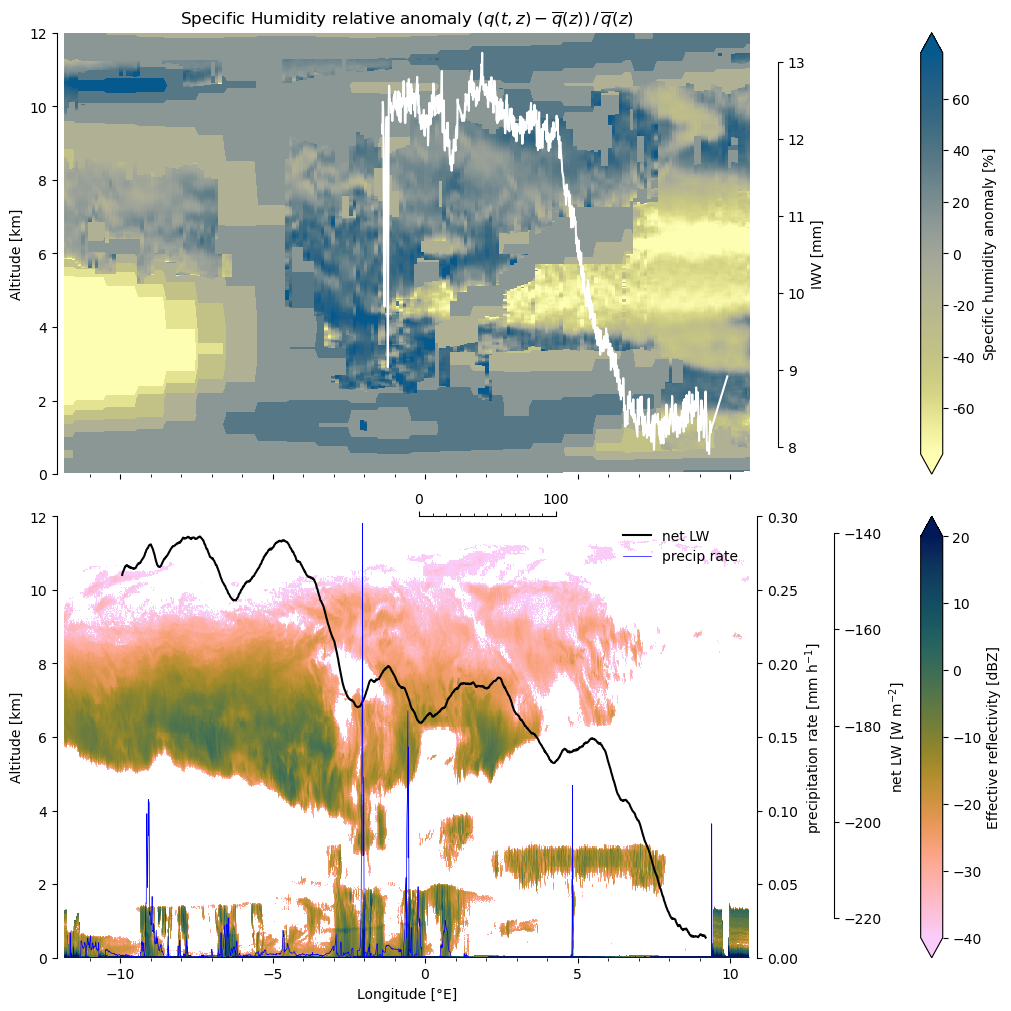

In [11]:
#plot specific humidity, radar and lidar signals and cloud ice for section 1

fig,axes=plt.subplots(2,1,figsize=(10,10),sharex=True, constrained_layout=True)

handles=[]

 # Slice the sections

sec_name='section_1'

sec_info = sections[sec_name]
secs = mdates.date2num(np.array(w_time_s, dtype='datetime64[s]'))    
start_idx = sec_info['start_idx']
end_idx = sec_info['end_idx']

v = np.nanpercentile(np.abs(q_anom_rel), 95)
    #norm = SymLogNorm(linthresh=0.1, linscale=1.0, vmin=-v, vmax=v, base=10)
norm=matplotlib.colors.Normalize(vmin=-v, vmax=v)

       
secs_section = secs[start_idx:end_idx+1]
lat_section = w_lat[start_idx:end_idx+1]
lon_section = w_lon[start_idx:end_idx+1]
data_section = q_anom_rel[start_idx:end_idx+1, :]  

# prepare time and coordinates as arrays for selecting ERA5 data along section    
ftime=xr.DataArray(data=np.array(w_time_s, dtype='datetime64[s]'),coords={'time':np.array(w_time_s, dtype='datetime64[s]')})
flat=xr.DataArray(data=w_lat,coords={'time':ftime})
flon=xr.DataArray(data=w_lon,coords={'time':ftime})

sectime=xr.DataArray(data=np.array(w_time_s, dtype='datetime64[s]')[sections[sec_name]['start_idx']:sections[sec_name]['end_idx']],coords={'time':np.array(w_time_s, dtype='datetime64[s]')[sections[sec_name]['start_idx']:sections[sec_name]['end_idx']]})
seclon=xr.DataArray(data=w_lon[sections[sec_name]['start_idx']:sections[sec_name]['end_idx']],coords={'time':sectime})
seclat=xr.DataArray(data=w_lat[sections[sec_name]['start_idx']:sections[sec_name]['end_idx']],coords={'time':sectime})

    #plot relative q anomaly from ERA5 along section

t2d = np.broadcast_to(seclon.values[:,None],fz.Z.sel(lon=seclon,lat=seclat,time=sectime,method='nearest').shape).transpose()
    #cm=fig.axes[0].contourf(t2d,fz.Z.sel(lon=seclon,lat=seclat,time=sectime,method='nearest').transpose()/9.81,compute_rh(f_t.var130.sel(lon=seclon,lat=seclat,time=sectime,method='nearest'),f_q.var133.sel(lon=seclon,lat=seclat,time=sectime,method='nearest'),f_t.plev).transpose(),levels=np.linspace(0.00,1.00,21),cmap=cmcr.nuuk_r,extend='both')

q_relanom_era=(f_q.var133.sel(lon=seclon,lat=seclat,time=sectime,method='nearest')-f_q.var133.sel(lon=flon[::120],lat=flat[::120],time=ftime[::120],method='nearest').mean(dim='time'))/f_q.var133.sel(lon=flon,lat=flat,time=ftime,method='nearest').mean(dim='time')

cm=axes[0].contourf(t2d,fz.Z.sel(lon=seclon,lat=seclat,time=sectime,method='nearest').transpose()/9.81/1000,q_relanom_era.transpose(),norm=norm,cmap=cmcr.nuuk_r,extend='both')

#plot WALES q anomaly
cm1=axes[0].pcolormesh(lon_section, w_alt/1000, np.flipud(np.rot90(data_section,1)), shading = 'auto', cmap = cmcr.nuuk_r, norm = norm, rasterized=True) #vmin=-v, vmax=v)
   
# plot radar reflectivity   
cm2 = axes[1].pcolormesh(ds.longitude.sel(time=slice(sectime[0],sectime[-1])), ds.altitude/1000, 10*np.log10(ds.radar_reflectivity.T.sel(time=slice(sectime[0],sectime[-1]))),cmap=cmcr.batlow_r,rasterized=True, vmin=-40, vmax=20)


#add axes for HAMP IWV, net LW and precip rate

#IWV

axh = axes[0].twinx()
axh.plot(f_iwv_obs.lon.sel(time=slice(sectime[0],sectime[-1])), f_iwv_obs.iwv.sel(time=slice(sectime[0],sectime[-1])), color='white', label='HAMP IWV')

#net LW
axh2 = axes[1].twinx()
l,=axh2.plot(f_rad.lon.sel(time=slice(sectime[0],sectime[-1])), f_rad.F_net_terrestrial.sel(time=slice(sectime[0],sectime[-1])).rolling(time=100).mean(), color='k', linestyle='-', label='net LW')
handles.append(l)
#precip rate
axh3 = axes[1].twinx()
l,=axh3.plot(f_precip.lon.sel(time=slice(sectime[0],sectime[-1])),f_precip.precip_rate.sel(time=slice(sectime[0],sectime[-1])), color='blue', linestyle='-', label='precip rate',linewidth=0.5)
handles.append(l)
# axes formatting

#axes[0].plot([f_ds03.lon[5,1].values,f_ds03.lon[5,1].values], [0,12], color='white', linestyle='dashed', label='DS 6',linewidth=0.5)
    #axes[0].plot([f_ds03.launch_time[7].values,f_ds03.launch_time[7].values], [0,12], color='white', linestyle='dashed', label='DS 7',linewidth=0.5)

axes[0].set_ylabel("Altitude [km]")
axes[1].set_ylabel("Altitude [km]")

axes[1].set_xlabel("Longitude [°E]")
axes[1].xaxis.set_minor_locator(AutoMinorLocator(5))

axes[0].set_ylim(0,12)
axes[1].set_ylim(0,12)

axes[0].spines["left"].set_visible(True)
axes[0].spines["left"].set_position(("outward", 5))  # shift
axes[1].spines["left"].set_visible(True)
axes[1].spines["left"].set_position(("outward", 5))  # shift


axh.set_ylabel('IWV [mm]')
axh.spines["right"].set_visible(True)
axh.spines["right"].set_position(("outward", 20))  # shift
axh.spines['right'].set_bounds(8, 13)

axh2.set_ylabel('net LW [W m$^{-2}$]')

#axh2.set_ylim(0,400)
axh2.spines["right"].set_position(("outward", 60))  # shift
axh2.spines["right"].set_visible(True)
axh2.spines['right'].set_bounds(-220, -140)

axh3.set_ylabel('precipitation rate [mm h$^{-1}$]')
axh3.spines["right"].set_position(("outward", 5))  # shift
axh3.spines["right"].set_visible(True)
axh3.set_ylim(0,0.3)

axy2 = axes[1].twiny()
axy2.plot(f_rad.dist_to_zero.sel(time=slice(sectime[0],sectime[-1])), f_rad.F_net_terrestrial.sel(time=slice(sectime[0],sectime[-1])).rolling(time=100).mean(), color='k', linestyle='-', label='net LW')
#axy2.spines["top"].set_position(("outward", 20))  # shift
axy2.spines["top"].set_visible(True)
axy2.set_xticks([0,100])
axy2.set_xticklabels(['0','100'])
axy2.spines['top'].set_bounds(0, 100)
axy2.xaxis.set_minor_locator(FixedLocator([10,20,30,40,50,60,70,80,90]))
cbar = plt.colorbar(mappable=cm1,extend = 'both', pad = 0.02)#, , format = mpl.ticker.LogFormatter(), ticks = mpl.ticker.LogLocator()) 
cbar.set_label(r"Specific humidity anomaly $[\%]$")

#cbar.ax.tick_params(which='minor', width=0, length=0, labelsize=0)
cbar.ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"{100*x:.0f}"))

cbar2 = plt.colorbar(mappable=cm2,extend = 'both', pad = 0.02)#, , format = mpl.ticker.LogFormatter(), ticks = mpl.ticker.LogLocator()) 
cbar2.set_label(r"Effective reflectivity [dBZ]")

     

axes[0].set_title("Specific Humidity relative anomaly "
r"$(q(t,z)-\overline{q}(z))\,/\,\overline{q}(z)$",
fontsize=12)

#add legend
axes[1].legend(loc='upper right',handles=handles,frameon=False)

plt.savefig('/Users/fpithan/Documents/haloac3_paper/hac3_combinedsection1_f3.pdf')

/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/var/folders/1s/m71688rd2kld26r435x91kbr76hw4s/T/ipykernel_28670/28462880.py:27: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ftime=xr.DataArray(data=np.array(w_time_s, dtype='datetime64[s]'),coords={'time':np.array(w_time_s, dtype='datetime64[s]')})
/var/folders/1s/m71688rd2kld26r435x91kbr76hw4s/T/ipykernel_28670/28462880.py:27: UserWarning: Converting non-nanosecond precision datet

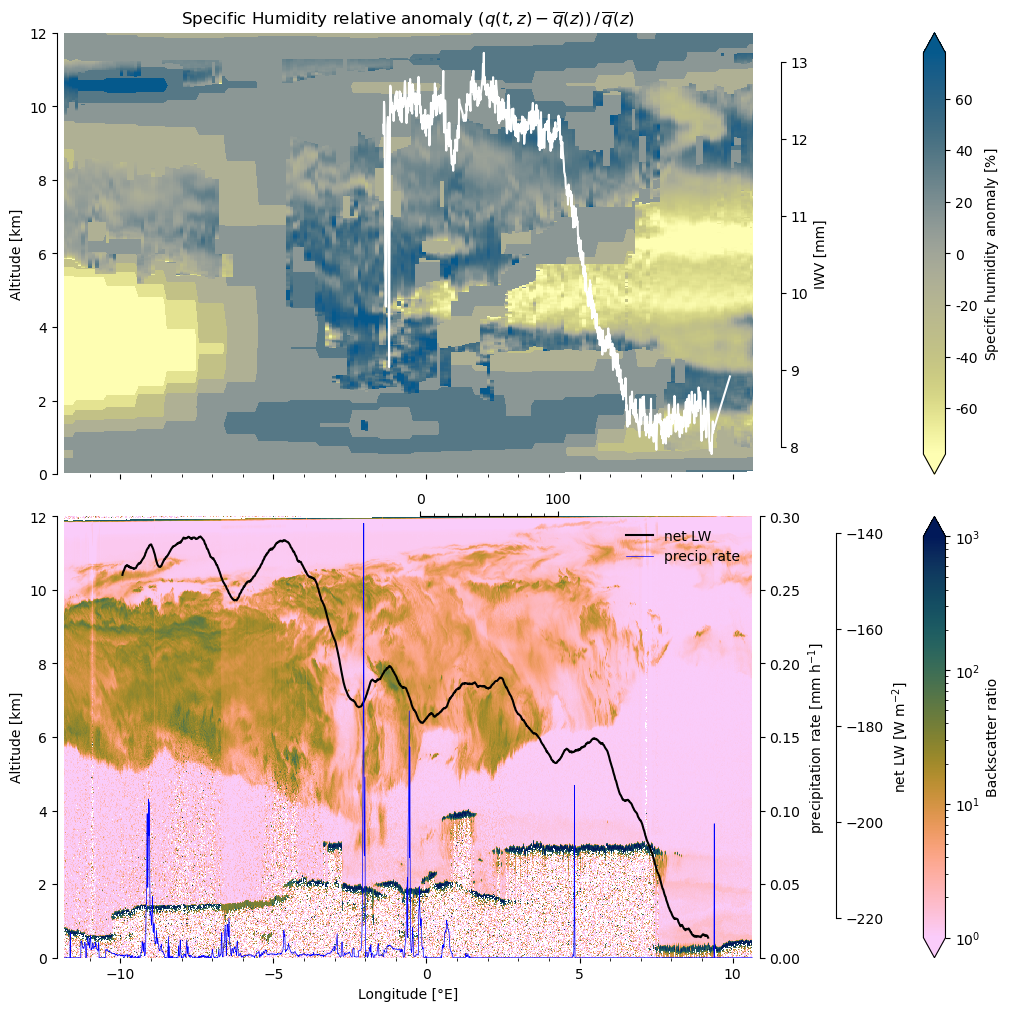

In [12]:
#plot specific humidity, radar and lidar signals and cloud ice for section 1

fig,axes=plt.subplots(2,1,figsize=(10,10),sharex=True, constrained_layout=True)

handles=[]

 # Slice the sections

sec_name='section_1'

sec_info = sections[sec_name]
secs = mdates.date2num(np.array(w_time_s, dtype='datetime64[s]'))    
start_idx = sec_info['start_idx']
end_idx = sec_info['end_idx']

v = np.nanpercentile(np.abs(q_anom_rel), 95)
    #norm = SymLogNorm(linthresh=0.1, linscale=1.0, vmin=-v, vmax=v, base=10)
norm=matplotlib.colors.Normalize(vmin=-v, vmax=v)

       
secs_section = secs[start_idx:end_idx+1]
lat_section = w_lat[start_idx:end_idx+1]
lon_section = w_lon[start_idx:end_idx+1]
data_section = q_anom_rel[start_idx:end_idx+1, :]  

# prepare time and coordinates as arrays for selecting ERA5 data along section    
ftime=xr.DataArray(data=np.array(w_time_s, dtype='datetime64[s]'),coords={'time':np.array(w_time_s, dtype='datetime64[s]')})
flat=xr.DataArray(data=w_lat,coords={'time':ftime})
flon=xr.DataArray(data=w_lon,coords={'time':ftime})

sectime=xr.DataArray(data=np.array(w_time_s, dtype='datetime64[s]')[sections[sec_name]['start_idx']:sections[sec_name]['end_idx']],coords={'time':np.array(w_time_s, dtype='datetime64[s]')[sections[sec_name]['start_idx']:sections[sec_name]['end_idx']]})
seclon=xr.DataArray(data=w_lon[sections[sec_name]['start_idx']:sections[sec_name]['end_idx']],coords={'time':sectime})
seclat=xr.DataArray(data=w_lat[sections[sec_name]['start_idx']:sections[sec_name]['end_idx']],coords={'time':sectime})

    #plot relative q anomaly from ERA5 along section

t2d = np.broadcast_to(seclon.values[:,None],fz.Z.sel(lon=seclon,lat=seclat,time=sectime,method='nearest').shape).transpose()
    #cm=fig.axes[0].contourf(t2d,fz.Z.sel(lon=seclon,lat=seclat,time=sectime,method='nearest').transpose()/9.81,compute_rh(f_t.var130.sel(lon=seclon,lat=seclat,time=sectime,method='nearest'),f_q.var133.sel(lon=seclon,lat=seclat,time=sectime,method='nearest'),f_t.plev).transpose(),levels=np.linspace(0.00,1.00,21),cmap=cmcr.nuuk_r,extend='both')

q_relanom_era=(f_q.var133.sel(lon=seclon,lat=seclat,time=sectime,method='nearest')-f_q.var133.sel(lon=flon[::120],lat=flat[::120],time=ftime[::120],method='nearest').mean(dim='time'))/f_q.var133.sel(lon=flon,lat=flat,time=ftime,method='nearest').mean(dim='time')

cm=axes[0].contourf(t2d,fz.Z.sel(lon=seclon,lat=seclat,time=sectime,method='nearest').transpose()/9.81/1000,q_relanom_era.transpose(),norm=norm,cmap=cmcr.nuuk_r,extend='both')

#plot WALES q anomaly
cm1=axes[0].pcolormesh(lon_section, w_alt/1000, np.flipud(np.rot90(data_section,1)), shading = 'auto', cmap = cmcr.nuuk_r, norm = norm, rasterized=True) #vmin=-v, vmax=v)
   
# plot backscatter ratio from WALES   
cm2 = axes[1].pcolormesh(f_bsr.longitude.sel(time=slice(sectime[0],sectime[-1])), f_bsr.altitude/1000, f_bsr.backscatter_ratio.T.sel(time=slice(sectime[0],sectime[-1])),cmap=cmcr.batlow_r,rasterized=True,norm=LogNorm(vmin=1, vmax=1000))


#add axes for HAMP IWV, net LW and precip rate

#IWV

axh = axes[0].twinx()
axh.plot(f_iwv_obs.lon.sel(time=slice(sectime[0],sectime[-1])), f_iwv_obs.iwv.sel(time=slice(sectime[0],sectime[-1])), color='white', label='HAMP IWV')

#net LW
axh2 = axes[1].twinx()
l,=axh2.plot(f_rad.lon.sel(time=slice(sectime[0],sectime[-1])), f_rad.F_net_terrestrial.sel(time=slice(sectime[0],sectime[-1])).rolling(time=100).mean(), color='k', linestyle='-', label='net LW')
handles.append(l)
#precip rate
axh3 = axes[1].twinx()
l,=axh3.plot(f_precip.lon.sel(time=slice(sectime[0],sectime[-1])),f_precip.precip_rate.sel(time=slice(sectime[0],sectime[-1])), color='blue', linestyle='-', label='precip rate',linewidth=0.5)
handles.append(l)
# axes formatting

#axes[0].plot([f_ds03.lon[5,1].values,f_ds03.lon[5,1].values], [0,12], color='white', linestyle='dashed', label='DS 6',linewidth=0.5)
    #axes[0].plot([f_ds03.launch_time[7].values,f_ds03.launch_time[7].values], [0,12], color='white', linestyle='dashed', label='DS 7',linewidth=0.5)

axes[0].set_ylabel("Altitude [km]")
axes[1].set_ylabel("Altitude [km]")

axes[1].set_xlabel("Longitude [°E]")
axes[1].xaxis.set_minor_locator(AutoMinorLocator(5))

axes[0].set_ylim(0,12)
axes[1].set_ylim(0,12)

axes[0].spines["left"].set_visible(True)
axes[0].spines["left"].set_position(("outward", 5))  # shift
axes[1].spines["left"].set_visible(True)
axes[1].spines["left"].set_position(("outward", 5))  # shift


axh.set_ylabel('IWV [mm]')
axh.spines["right"].set_visible(True)
axh.spines["right"].set_position(("outward", 20))  # shift
axh.spines['right'].set_bounds(8, 13)

axh2.set_ylabel('net LW [W m$^{-2}$]')

#axh2.set_ylim(0,400)
axh2.spines["right"].set_position(("outward", 60))  # shift
axh2.spines["right"].set_visible(True)
axh2.spines['right'].set_bounds(-220, -140)

axh3.set_ylabel('precipitation rate [mm h$^{-1}$]')
axh3.spines["right"].set_position(("outward", 5))  # shift
axh3.spines["right"].set_visible(True)
axh3.set_ylim(0,0.3)

axy2 = axes[1].twiny()
axy2.plot(f_rad.dist_to_zero.sel(time=slice(sectime[0],sectime[-1])), f_rad.F_net_terrestrial.sel(time=slice(sectime[0],sectime[-1])).rolling(time=100).mean(), color='k', linestyle='-', label='net LW')
#axy2.spines["top"].set_position(("outward", 20))  # shift
axy2.spines["top"].set_visible(True)
axy2.set_xticks([0,100])
axy2.set_xticklabels(['0','100'])
axy2.spines['top'].set_bounds(0, 100)
axy2.xaxis.set_minor_locator(FixedLocator([10,20,30,40,50,60,70,80,90]))
cbar = plt.colorbar(mappable=cm1,extend = 'both', pad = 0.02)#, , format = mpl.ticker.LogFormatter(), ticks = mpl.ticker.LogLocator()) 
cbar.set_label(r"Specific humidity anomaly $[\%]$")

#cbar.ax.tick_params(which='minor', width=0, length=0, labelsize=0)
cbar.ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"{100*x:.0f}"))

cbar2 = plt.colorbar(mappable=cm2,extend = 'both', pad = 0.02)#, , format = mpl.ticker.LogFormatter(), ticks = mpl.ticker.LogLocator()) 
cbar2.set_label(r"Backscatter ratio")

     

axes[0].set_title("Specific Humidity relative anomaly "
r"$(q(t,z)-\overline{q}(z))\,/\,\overline{q}(z)$",
fontsize=12)

#add legend
axes[1].legend(loc='upper right',handles=handles,frameon=False)

plt.savefig('/Users/fpithan/Documents/haloac3_paper/hac3_combinedsection1_f3SI.pdf')

/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/var/folders/1s/m71688rd2kld26r435x91kbr76hw4s/T/ipykernel_28670/2180045218.py:27: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ftime=xr.DataArray(data=np.array(w_time_s, dtype='datetime64[s]'),coords={'time':np.array(w_time_s, dtype='datetime64[s]')})
/var/folders/1s/m71688rd2kld26r435x91kbr76hw4s/T/ipykernel_28670/2180045218.py:27: UserWarning: Converting non-nanosecond precision d

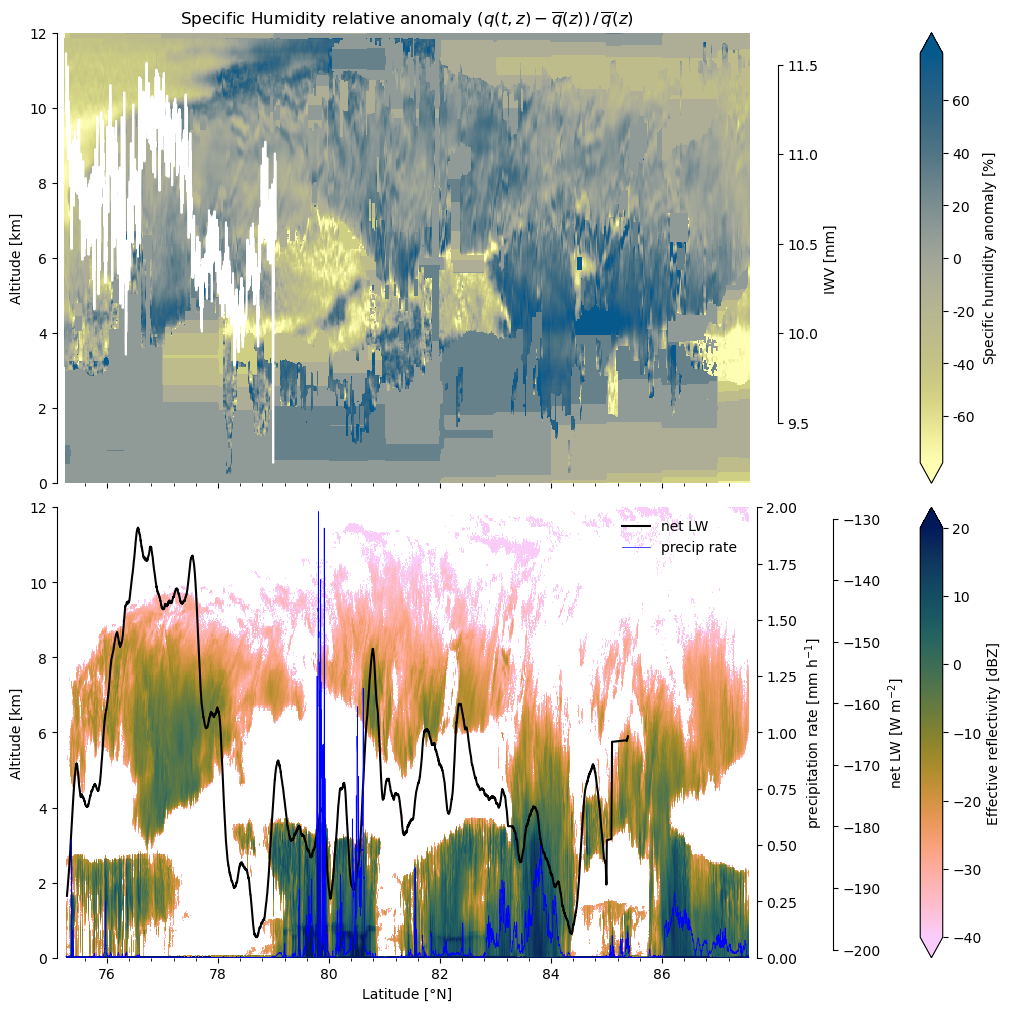

In [13]:
##plot specific humidity, radar and lidar signals and cloud ice for section 10

fig,axes=plt.subplots(2,1,figsize=(10,10),sharex=True, constrained_layout=True)

handles=[]

 # Slice the sections

sec_name='section_10'

sec_info = sections[sec_name]
secs = mdates.date2num(np.array(w_time_s, dtype='datetime64[s]'))    
start_idx = sec_info['start_idx']
end_idx = sec_info['end_idx']

v = np.nanpercentile(np.abs(q_anom_rel), 95)
    #norm = SymLogNorm(linthresh=0.1, linscale=1.0, vmin=-v, vmax=v, base=10)
norm=matplotlib.colors.Normalize(vmin=-v, vmax=v)

       
secs_section = secs[start_idx:end_idx+1]
lat_section = w_lat[start_idx:end_idx+1]
lon_section = w_lon[start_idx:end_idx+1]
data_section = q_anom_rel[start_idx:end_idx+1, :]  

# prepare time and coordinates as arrays for selecting ERA5 data along section    
ftime=xr.DataArray(data=np.array(w_time_s, dtype='datetime64[s]'),coords={'time':np.array(w_time_s, dtype='datetime64[s]')})
flat=xr.DataArray(data=w_lat,coords={'time':ftime})
flon=xr.DataArray(data=w_lon,coords={'time':ftime})

sectime=xr.DataArray(data=np.array(w_time_s, dtype='datetime64[s]')[sections[sec_name]['start_idx']:sections[sec_name]['end_idx']],coords={'time':np.array(w_time_s, dtype='datetime64[s]')[sections[sec_name]['start_idx']:sections[sec_name]['end_idx']]})
seclon=xr.DataArray(data=w_lon[sections[sec_name]['start_idx']:sections[sec_name]['end_idx']],coords={'time':sectime})
seclat=xr.DataArray(data=w_lat[sections[sec_name]['start_idx']:sections[sec_name]['end_idx']],coords={'time':sectime})

    #plot relative q anomaly from ERA5 along section

t2d = np.broadcast_to(seclat.values[:,None],fz.Z.sel(lon=seclon,lat=seclat,time=sectime,method='nearest').shape).transpose()
    #cm=fig.axes[0].contourf(t2d,fz.Z.sel(lon=seclon,lat=seclat,time=sectime,method='nearest').transpose()/9.81,compute_rh(f_t.var130.sel(lon=seclon,lat=seclat,time=sectime,method='nearest'),f_q.var133.sel(lon=seclon,lat=seclat,time=sectime,method='nearest'),f_t.plev).transpose(),levels=np.linspace(0.00,1.00,21),cmap=cmcr.nuuk_r,extend='both')

q_relanom_era=(f_q.var133.sel(lon=seclon,lat=seclat,time=sectime,method='nearest')-f_q.var133.sel(lon=flon[::120],lat=flat[::120],time=ftime[::120],method='nearest').mean(dim='time'))/f_q.var133.sel(lon=flon,lat=flat,time=ftime,method='nearest').mean(dim='time')

cm=axes[0].contourf(t2d,fz.Z.sel(lon=seclon,lat=seclat,time=sectime,method='nearest').transpose()/9.81/1000,q_relanom_era.transpose(),norm=norm,cmap=cmcr.nuuk_r,extend='both')

#plot WALES q anomaly
cm1=axes[0].pcolormesh(lat_section, w_alt/1000, np.flipud(np.rot90(data_section,1)), shading = 'auto', cmap = cmcr.nuuk_r, norm = norm, rasterized=True) #vmin=-v, vmax=v)
   
# plot radar reflectivity   
cm2 = axes[1].pcolormesh(ds.latitude.sel(time=slice(sectime[0],sectime[-1])), ds.altitude/1000, 10*np.log10(ds.radar_reflectivity.T.sel(time=slice(sectime[0],sectime[-1]))),cmap=cmcr.batlow_r,rasterized=True, vmin=-40, vmax=20)


#add axes for HAMP IWV, net LW and precip rate

#IWV

axh = axes[0].twinx()
axh.plot(f_iwv_obs.lat.sel(time=slice(sectime[0],sectime[-1])), f_iwv_obs.iwv.sel(time=slice(sectime[0],sectime[-1])), color='white', label='HAMP IWV')

#net LW
axh2 = axes[1].twinx()
l,=axh2.plot(f_rad.lat.sel(time=slice(sectime[0],sectime[-1])), f_rad.F_net_terrestrial.sel(time=slice(sectime[0],sectime[-1])).rolling(time=100).mean(), color='k', linestyle='-', label='net LW')
handles.append(l)
#precip rate
axh3 = axes[1].twinx()
l,=axh3.plot(f_precip.lat.sel(time=slice(sectime[0],sectime[-1])),f_precip.precip_rate.sel(time=slice(sectime[0],sectime[-1])), color='blue', linestyle='-', label='precip rate',linewidth=0.5)
handles.append(l)
# axes formatting

#axes[0].plot([f_ds03.lon[5,1].values,f_ds03.lon[5,1].values], [0,12], color='white', linestyle='dashed', label='DS 6',linewidth=0.5)
    #axes[0].plot([f_ds03.launch_time[7].values,f_ds03.launch_time[7].values], [0,12], color='white', linestyle='dashed', label='DS 7',linewidth=0.5)

axes[0].set_ylabel("Altitude [km]")
axes[1].set_ylabel("Altitude [km]")

axes[1].set_xlabel("Latitude [°N]")
axes[1].xaxis.set_minor_locator(AutoMinorLocator(5))

axes[0].set_ylim(0,12)
axes[1].set_ylim(0,12)

axes[0].spines["left"].set_visible(True)
axes[0].spines["left"].set_position(("outward", 5))  # shift
axes[1].spines["left"].set_visible(True)
axes[1].spines["left"].set_position(("outward", 5))  # shift


axh.set_ylabel('IWV [mm]')
axh.spines["right"].set_visible(True)
axh.spines["right"].set_position(("outward", 20))  # shift
axh.spines['right'].set_bounds(9.5, 11.5)

axh2.set_ylabel('net LW [W m$^{-2}$]')

#axh2.set_ylim(0,400)
axh2.spines["right"].set_position(("outward", 60))  # shift
axh2.spines["right"].set_visible(True)
axh2.spines['right'].set_bounds(-200, -130)

axh3.set_ylabel('precipitation rate [mm h$^{-1}$]')
axh3.spines["right"].set_position(("outward", 5))  # shift
axh3.spines["right"].set_visible(True)
axh3.set_ylim(0,2)

#axy2 = axes[1].twiny()
#axy2.plot(f_rad.dist_to_zero.sel(time=slice(sectime[0],sectime[-1])), f_rad.F_net_terrestrial.sel(time=slice(sectime[0],sectime[-1])).rolling(time=100).mean(), color='k', linestyle='-', label='net LW')
#axy2.spines["top"].set_position(("outward", 20))  # shift
#axy2.spines["top"].set_visible(True)
#axy2.set_xticks([0,100])
#axy2.set_xticklabels(['0','100'])
#axy2.spines['top'].set_bounds(0, 100)
#axy2.xaxis.set_minor_locator(FixedLocator([10,20,30,40,50,60,70,80,90]))
cbar = plt.colorbar(mappable=cm1,extend = 'both', pad = 0.02)#, , format = mpl.ticker.LogFormatter(), ticks = mpl.ticker.LogLocator()) 
cbar.set_label(r"Specific humidity anomaly $[\%]$")

#cbar.ax.tick_params(which='minor', width=0, length=0, labelsize=0)
cbar.ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"{100*x:.0f}"))

cbar2 = plt.colorbar(mappable=cm2,extend = 'both', pad = 0.02)#, , format = mpl.ticker.LogFormatter(), ticks = mpl.ticker.LogLocator()) 
cbar2.set_label(r"Effective reflectivity [dBZ]")

     

axes[0].set_title("Specific Humidity relative anomaly "
r"$(q(t,z)-\overline{q}(z))\,/\,\overline{q}(z)$",
fontsize=12)

#add legend
axes[1].legend(loc='upper right',handles=handles,frameon=False)

plt.savefig('/Users/fpithan/Documents/haloac3_paper/hac3_combinedsection10_f3SI.pdf')

/var/folders/1s/m71688rd2kld26r435x91kbr76hw4s/T/ipykernel_28670/3824930343.py:10: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  sectime=xr.DataArray(data=np.array(w_time_s, dtype='datetime64[s]')[start_idx:end_idx],coords={'time':np.array(w_time_s, dtype='datetime64[s]')[start_idx:end_idx]})
/var/folders/1s/m71688rd2kld26r435x91kbr76hw4s/T/ipykernel_28670/3824930343.py:10: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-n

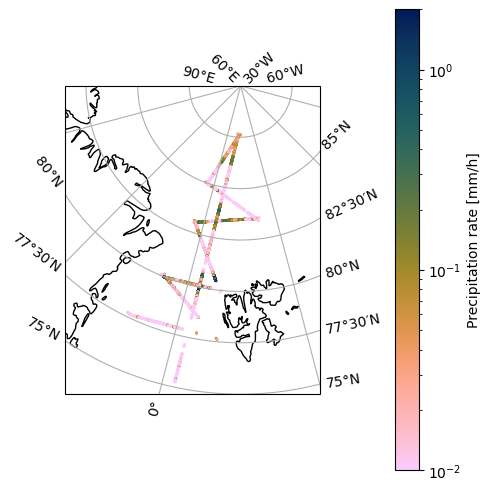

In [14]:
# plot map of precipitation along flight track for SI
#define Figure
w,h=plt.figaspect(1)
fig=plt.figure(figsize=(w,h),constrained_layout=True)

handles=[]

start_idx = 410 #sec_info['start_idx']
end_idx = 2078 #sec_info['end_idx']
sectime=xr.DataArray(data=np.array(w_time_s, dtype='datetime64[s]')[start_idx:end_idx],coords={'time':np.array(w_time_s, dtype='datetime64[s]')[start_idx:end_idx]})
seclat=xr.DataArray(data=w_lat[start_idx:end_idx],coords={'time':sectime})
seclon=xr.DataArray(data=w_lon[start_idx:end_idx],coords={'time':sectime})

q_relanom_era=(f_q.var133.sel(lon=seclon,lat=seclat,time=sectime,method='nearest')-f_q.var133.sel(lon=flon[::120],lat=flat[::120],time=ftime[::120],method='nearest').mean(dim='time'))/f_q.var133.sel(lon=flon,lat=flat,time=ftime,method='nearest').mean(dim='time')


#define map of Fram strait
ax = plt.axes(projection=ccrs.TransverseMercator(central_longitude=15.0, central_latitude=75.0, false_easting=0.0, false_northing=0.0, scale_factor=1.0, globe=None, approx=None))
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)


#cm=ax.contour(f_q.lon,f_q.lat,f_tcwv.var137.sel(time=stime,method='nearest'),transform=ccrs.PlateCarree(),levels=np.linspace(0,20,20),color='k')






    
cm=ax.scatter(f_precip.lon.sel(time=slice(sectime[0],sectime[-1])),f_precip.lat.sel(time=slice(sectime[0],sectime[-1])),c=f_precip.precip_rate.sel(time=slice(sectime[0],sectime[-1])),cmap=cmcr.batlow_r, vmin=1e-2,vmax=2,label=sec_name,s=1,transform=ccrs.PlateCarree(),norm='log')

plt.colorbar(cm, label='Precipitation rate [mm/h]')

#plot settings
cbar.set_label('precipitable water [mm]')
ax.set_extent([-20, 30, 75, 90], crs=ccrs.PlateCarree())
#ax.set_title('ERA5 precipitable water on '+stime,pad=20)
ax.coastlines()
plt.savefig('/Users/fpithan/Documents/haloac3_paper/hac3_precip_map_SI.pdf')

In [15]:
a=[0.00000000,2.00036500,3.10224100,4.66608400,6.82797700,9.74696600,13.60542400,18.60893100,24.98571800,32.98571000,42.87924200,54.95546300,69.52057600,86.89588200,107.41574100,131.42550700,159.27940400,191.33856200,227.96894800,269.53958100,316.42074600,368.98236100,427.59249900,492.61602800,564.41345200,643.33990500,729.74414100,823.96783400,926.34491000,1037.20117200,1156.85363800,1285.61035200,1423.77014200,1571.62292500,1729.44897500,1897.51928700,2076.09594700,2265.43164100,2465.77050800,2677.34814500,2900.39135700,3135.11938500,3381.74365200,3640.46826200,3911.49047900,4194.93066400,4490.81738300,4799.14941400,5119.89502000,5452.99072300,5798.34472700,6156.07421900,6526.94677700,6911.87060500,7311.86914100,7727.41210900,8159.35400400,8608.52539100,9076.40039100,9562.68261700,10065.97851600,10584.63183600,11116.66210900,11660.06738300,12211.54785200,12766.87304700,13324.66894500,13881.33105500,14432.13964800,14975.61523400,15508.25683600,16026.11523400,16527.32226600,17008.78906300,17467.61328100,17901.62109400,18308.43359400,18685.71875000,19031.28906300,19343.51171900,19620.04296900,19859.39062500,20059.93164100,20219.66406300,20337.86328100,20412.30859400,20442.07812500,20425.71875000,20361.81640600,20249.51171900,20087.08593800,19874.02539100,19608.57226600,19290.22656300,18917.46093800,18489.70703100,18006.92578100,17471.83984400,16888.68750000,16262.04687500,15596.69531300,14898.45312500,14173.32421900,13427.76953100,12668.25781300,11901.33984400,11133.30468800,10370.1757810,9617.51562500,8880.45312500,8163.37500000,7470.34375000,6804.42187500,6168.53125000,5564.38281300,4993.79687500,4457.37500000,3955.96093800,3489.23437500,3057.26562500,2659.14062500,2294.24218800,1961.50000000,1659.47656300,1387.54687500,1143.2500000,926.50781300,734.99218800,568.06250000,424.41406300,302.47656300,202.48437500,122.10156300,62.78125000,22.83593800,3.75781300,0.00000000,0.00000000]
b=[0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000700,0.00002400,0.00005900,0.00011200,0.00019900,0.00034000,0.00056200,0.00089000,0.00135300,0.00199200,0.00285700,0.00397100,0.00537800,0.00713300,0.00926100,0.01180600,0.01481600,0.01831800,0.02235500,0.02696400,0.03217600,0.03802600,0.04454800,0.05177300,0.05972800,0.06844800,0.07795800,0.08828600,0.09946200,0.11150500,0.12444800,0.13831300,0.15312500,0.16891000,0.18568900,0.20349100,0.22233300,0.24224400,0.26324200,0.28535400,0.30859800,0.33293900,0.35825400,0.38436300,0.41112500,0.43839100,0.46600300,0.49380000,0.52161900,0.54930100,0.57669200,0.60364800,0.63003600,0.65573600,0.68064300,0.70466900,0.72773900,0.74979700,0.77079800,0.79071700,0.80953600,0.82725600,0.84388100,0.85943200,0.87392900,0.88740800,0.89990000,0.91144800,0.92209600,0.93188100,0.94086000,0.94906400,0.95655000,0.96335200,0.96951300,0.97507800,0.98007200,0.98454200,0.98850000,0.99198400,0.99500300,0.99763000,1.00000000]




Text(0.5, 102.72222222222219, 'longitude relative to maximum moisture anomaly')

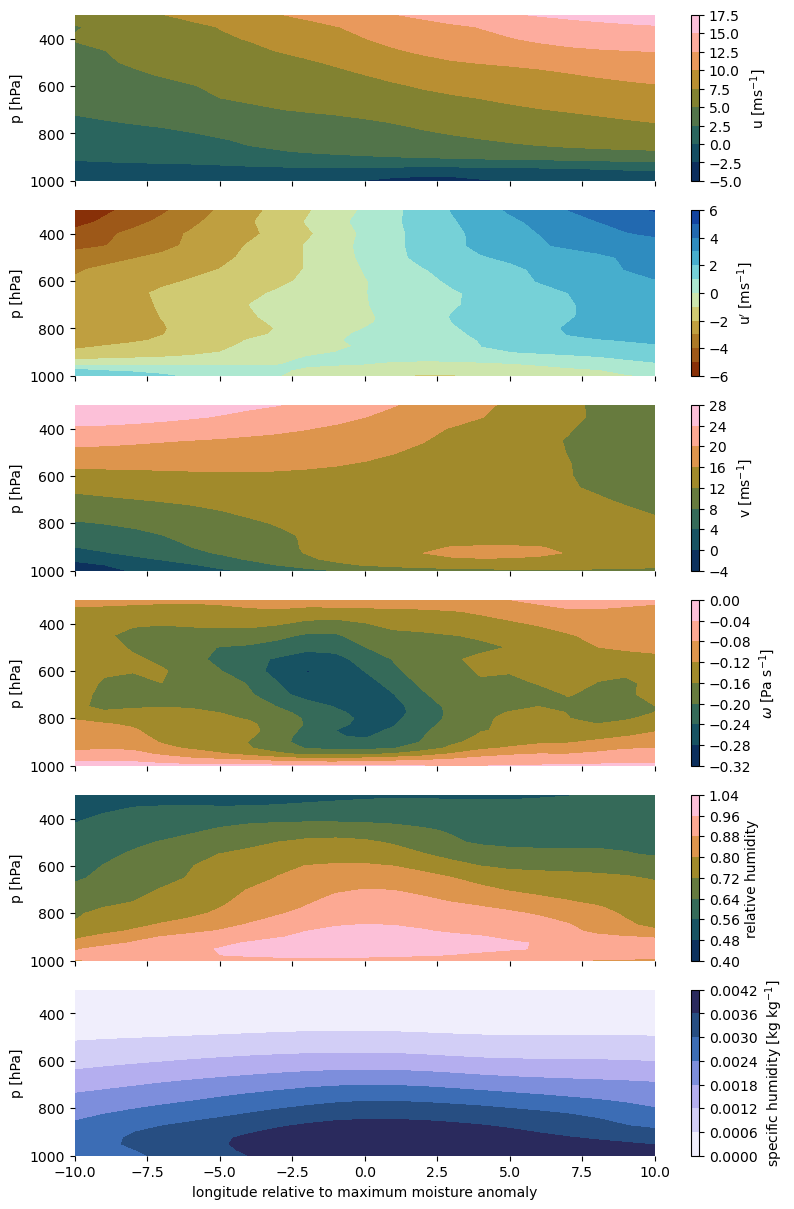

In [16]:
# composite of moist intrusions over Fram Strait
# developed based on suggestions by chatgpt

#from cdo import *   # python version
#cdo = Cdo()

#define timeframe of analysis

ystart=1979
yend=2023

sellat=76

comp_cdo=False # false to not produce data files again




# Load ERA5 data
e5ds = xr.open_dataset(datdir+'/era5_tcwv_FS_all.nc').sel(time=slice('1979','2023')).convert_calendar('365_day')

if comp_cdo:
    # Loop over years and remap ERA5 data to section grid based on levante data pool
    for y in range(ystart,yend+1):

        folder_path = "/pool/data/ERA5/E5/sf/an/1H/134/"
        string_to_match = "*"+str(y)+"*.grb"
        output_file = "/scratch/a/a270082/"+str(y)+"_era5_ps.nc"

        remap_files(folder_path, string_to_match, output_file)



#131,132,135, u,v,w

e5dsu=xr.open_dataset(datdir+'u_ERA5_1979_2023_FS.nc').convert_calendar('365_day')
e5dsv=xr.open_dataset(datdir+'v_ERA5_1979_2023_FS.nc').convert_calendar('365_day')
e5dsw=xr.open_dataset(datdir+'w_ERA5_1979_2023_FS.nc').convert_calendar('365_day')
e5dst=xr.open_dataset(datdir+'t_ERA5_1979_2023_FS.nc').convert_calendar('365_day')
e5dsq=xr.open_dataset(datdir+'q_ERA5_1979_2023_FS.nc').convert_calendar('365_day')


# Selecting the cross-section from 30 W to 30 E at selected latitude
cross_section = e5ds.var137.sel(lat=sellat,method='nearest').sel(lon=slice(-30, 30))

# Select only the time step at 0 UTC on each day
cross_section = cross_section.sel(time=cross_section.time.dt.hour == 0)

# Compute daily climatology using a ten-day running mean centered on each day
climatology = cross_section.groupby('time.dayofyear').mean().rolling(dayofyear=10, center=True).mean()

# Compute anomaly
anomaly = cross_section
for nta,tsa in enumerate(anomaly.time):
    anomaly[nta,:]=cross_section.sel(time=tsa)-climatology.sel(dayofyear=cross_section.sel(time=tsa).time.dt.dayofyear)
    
# Compute maximum anomaly
max_anomaly = anomaly.max(dim=['lon'],skipna=True)

# Compute 90th percentile of maximum anomaly
percentile_90 = np.nanpercentile(max_anomaly, 90)

# Find dates where maximum anomaly is larger than the 90th percentile
anomaly_dates = max_anomaly[max_anomaly > percentile_90].time.where(max_anomaly.time.dt.month.isin([1,2,3,4,11,12]),drop=True)

# Find longitude where maximum anomaly occurs
#lon_max_anomaly = anomaly.sel(time=anomaly_dates).argmax(dim=['lon'])['lon'].values
#Find longitude of max pw during anomaly dates
lon_max_anomaly = cross_section.sel(time=anomaly_dates).argmax(dim=['lon'])['lon'].values

pw=cross_section.sel(time=anomaly_dates)
zonal_wind = e5dsu.var131.sel(lat=sellat,method='nearest').sel(plev=slice(20000,100000)).sel(time=anomaly_dates)
meridional_wind = e5dsv.var132.sel(lat=sellat,method='nearest').sel(plev=slice(20000,100000)).sel(time=anomaly_dates)
vertical_velocity = e5dsw.var135.sel(lat=sellat,method='nearest').sel( plev=slice(20000,100000)).sel(time=anomaly_dates)
temp = e5dst.var130.sel(lat=sellat,method='nearest').sel( plev=slice(20000,100000)).sel(time=anomaly_dates)
q = e5dsq.var133.sel(lat=sellat,method='nearest').sel( plev=slice(20000,100000)).sel(time=anomaly_dates)



# Convert longitude to horizontal distance from maximum anomaly


zonal_wind_miref = zonal_wind*np.nan
zonal_wind_miref_a = zonal_wind*np.nan
meridional_wind_miref = zonal_wind*np.nan
vertical_velocity_miref = zonal_wind*np.nan
temp_miref=zonal_wind*np.nan
q_miref=q*np.nan
pw_miref=pw*np.nan

for nt,t in enumerate(zonal_wind.time): 
    if (lon_max_anomaly[nt]<25 or lon_max_anomaly[nt]>35): 
        continue
    lonw=zonal_wind.lon[lon_max_anomaly[nt]-10]
    lone=zonal_wind.lon[lon_max_anomaly[nt]+10]
    zonal_wind_miref[nt,:,20:41]=(zonal_wind.sel(time=t,lon=slice(lonw,lone))-zonal_wind.sel(time=t,lon=slice(lonw,lone)).mean(dim='lon')).values
    zonal_wind_miref_a[nt,:,20:41]=zonal_wind.sel(time=t,lon=slice(lonw,lone)).values
    meridional_wind_miref[nt,:,20:41]=(meridional_wind.sel(time=t,lon=slice(lonw,lone))).values 
    vertical_velocity_miref[nt,:,20:41]=(vertical_velocity.sel(time=t,lon=slice(lonw,lone))).values
    temp_miref[nt,:,20:41]=(temp.sel(time=t,lon=slice(lonw,lone))).values
    q_miref[nt,:,20:41]=(q.sel(time=t,lon=slice(lonw,lone))).values
    pw_miref[nt,20:41]=(pw.sel(time=t,lon=slice(lonw,lone))).values
    
#meridional_wind = meridional_wind.assign_coords(lon=(meridional_wind.lon - lon_max_anomaly) * np.cos(np.radians(75)) * 111.32)

# Retrieve vertical velocity

# Convert longitude to horizontal distance from maximum anomaly
#vertical_velocity = vertical_velocity.assign_coords(lon=(vertical_velocity.lon - lon_max_anomaly) * np.cos(np.radians(75)) * 111.32)

w, h = matplotlib.figure.figaspect(1.5)

fig,[ax1,ax2,ax3,ax4,ax5,ax6]=plt.subplots(6,1,sharex=True,figsize=(2*w,2*h))
cm1=ax1.contourf(zonal_wind_miref_a.lon,zonal_wind_miref_a.plev/100,zonal_wind_miref_a.mean('time',skipna=True),cmap=cmcr.batlow)
ax1.invert_yaxis()
cbar=plt.colorbar(cm1,ax=ax1)
cbar.ax.set_ylabel('u [ms$^{-1}$]')
cm2=ax2.contourf(zonal_wind_miref.lon,zonal_wind_miref.plev/100,zonal_wind_miref.mean('time',skipna=True),cmap=cmcr.roma,levels=10)
ax2.invert_yaxis()
cbar=plt.colorbar(cm2,ax=ax2)
cbar.ax.set_ylabel('u$\'$ [ms$^{-1}$]')
cm3=ax3.contourf(meridional_wind_miref.lon,meridional_wind_miref.plev/100,meridional_wind_miref.mean('time',skipna=True),cmap=cmcr.batlow)
ax3.invert_yaxis()
cbar=plt.colorbar(cm3,ax=ax3)
cbar.ax.set_ylabel('v [ms$^{-1}$]')
cm4=ax4.contourf(vertical_velocity_miref.lon,vertical_velocity_miref.plev/100,vertical_velocity_miref.mean('time',skipna=True),cmap=cmcr.batlow)
ax4.invert_yaxis()
cbar=plt.colorbar(cm4,ax=ax4)
cbar.ax.set_ylabel('$\omega$ [Pa s$^{-1}$]')

#cm5=ax5.contourf(zonal_wind_miref_a.lon,zonal_wind_miref_a.plev,((zonal_wind_miref_a**2+meridional_wind_miref**2)**0.5).mean('time',skipna=True),cmap=cmcr.batlow)
#ax5.invert_yaxis()
#cbar=plt.colorbar(cm5,ax=ax5)
#cbar.ax.set_ylabel('wind speed')


cm5=ax5.contourf(temp_miref.lon,zonal_wind_miref.plev/100,compute_rh(temp_miref,q_miref,temp_miref.plev).mean('time',skipna=True),cmap=cmcr.batlow)
ax5.invert_yaxis()
cbar=plt.colorbar(cm5,ax=ax5)
cbar.ax.set_ylabel('relative humidity')

cm6=ax6.contourf(q_miref.lon,q_miref.plev/100,q_miref.mean('time',skipna=True),cmap=cmcr.devon_r)
ax6.invert_yaxis()
cbar=plt.colorbar(cm6,ax=ax6)
cbar.ax.set_ylabel('specific humidity [kg kg$^{-1}$]')

fig.tight_layout()

ax1.set_xlim(-10,10)
ax1.set_ylabel('p [hPa]')
ax2.set_ylabel('p [hPa]')
ax3.set_ylabel('p [hPa]')
ax4.set_ylabel('p [hPa]')
ax5.set_ylabel('p [hPa]')
ax6.set_ylabel('p [hPa]')
ax6.set_xlabel('longitude relative to maximum moisture anomaly')

In [17]:
# composite of moist intrusions over Fram Strait
# developed based on suggestions by chatgpt

#from cdo import *   # python version
#cdo = Cdo()

#define timeframe of analysis

ystart=1979
yend=2023

sellat=79
pcore=85000

comp_cdo=False # false to not produce data files again




# Load ERA5 data
#e5ds = xr.open_dataset(datdir+'/era5_tcwv_FS_all.nc').sel(time=slice('1979','2023')).convert_calendar('365_day')

if comp_cdo:
    for y in range(ystart,yend+1):

        folder_path = "/pool/data/ERA5/E5/sf/an/1H/134/"
        string_to_match = "*"+str(y)+"*.grb"
        output_file = "/scratch/a/a270082/"+str(y)+"_era5_ps.nc"

        remap_files(folder_path, string_to_match, output_file)



#131,132,135, u,v,w

#e5dsu=xr.open_dataset(datdir+'u_ERA5_1979_2023_FS.nc').convert_calendar('365_day')
#e5dsv=xr.open_dataset(datdir+'v_ERA5_1979_2023_FS.nc').convert_calendar('365_day')
#e5dsw=xr.open_dataset(datdir+'w_ERA5_1979_2023_FS.nc').convert_calendar('365_day')
#e5dst=xr.open_dataset(datdir+'t_ERA5_1979_2023_FS.nc').convert_calendar('365_day')
#e5dsq=xr.open_dataset(datdir+'q_ERA5_1979_2023_FS.nc').convert_calendar('365_day')


# Selecting the cross-section from 30 W to 30 E at selected latitude
cross_section = e5ds.var137.sel(lat=sellat,method='nearest').sel(lon=slice(-30, 30))

# Select only the time step at 0 UTC on each day
cross_section = cross_section.sel(time=cross_section.time.dt.hour == 0)

# Compute daily climatology using a ten-day running mean centered on each day
climatology = cross_section.groupby('time.dayofyear').mean().rolling(dayofyear=10, center=True).mean()

# Compute anomaly
anomaly = cross_section
for nta,tsa in enumerate(anomaly.time):
    anomaly[nta,:]=cross_section.sel(time=tsa)-climatology.sel(dayofyear=cross_section.sel(time=tsa).time.dt.dayofyear)
    
# Compute maximum anomaly
max_anomaly = anomaly.max(dim=['lon'],skipna=True)

# Compute 90th percentile of maximum anomaly
percentile_90 = np.nanpercentile(max_anomaly, 90)

# Find dates where maximum anomaly is larger than the 90th percentile
anomaly_dates = max_anomaly[max_anomaly > percentile_90].time.where(max_anomaly.time.dt.month.isin([1,2,3,4,11,12]),drop=True)

# Find longitude where maximum anomaly occurs
#lon_max_anomaly = anomaly.sel(time=anomaly_dates).argmax(dim=['lon'])['lon'].values
#Find longitude of max pw during anomaly dates
lon_max_anomaly = cross_section.sel(time=anomaly_dates).argmax(dim=['lon'])['lon'].values

#orient cross-section perpendicular to mean wind

u_c=[]
up_c=[]
v_c=[]
w_c=[]
t_c=[]
q_c=[]

for nt,t in enumerate(anomaly_dates.time): 
    if (lon_max_anomaly[nt]<25 or lon_max_anomaly[nt]>35): 
        continue
    ucore=e5dsu.var131.sel(time=t,lat=sellat,lon=e5dsu.lon[lon_max_anomaly[nt]],plev=pcore,method='nearest')
    vcore=e5dsv.var132.sel(time=t,lat=sellat,lon=e5dsu.lon[lon_max_anomaly[nt]],plev=pcore,method='nearest')
    lons_t=e5dsu.lon[lon_max_anomaly[nt]-10:lon_max_anomaly[nt]+10]    
    lats_t=sellat-(ucore.values/vcore.values)*(lons_t-e5dsu.lon[lon_max_anomaly[nt]])

    if max(lats_t)>85 or min(lats_t<75):
        continue
    pw=e5ds.var137.sel(time=t,lat=lats_t,lon=lons_t,method='nearest')

    zonal_wind = e5dsu.var131.sel(time=t,lat=lats_t,lon=lons_t,method='nearest').sel(plev=slice(20000,100000))
    meridional_wind = e5dsv.var132.sel(time=t,lat=lats_t,lon=lons_t,method='nearest').sel(plev=slice(20000,100000))
    vertical_velocity = e5dsw.var135.sel(time=t,lat=lats_t,lon=lons_t,method='nearest').sel( plev=slice(20000,100000))
    temp = e5dst.var130.sel(time=t,lat=lats_t,lon=lons_t,method='nearest').sel( plev=slice(20000,100000))
    q = e5dsq.var133.sel(time=t,lat=lats_t,lon=lons_t,method='nearest').sel( plev=slice(20000,100000))


    #wind projected on transect
    core = xr.DataArray([vcore, -ucore], dims=["component"])
    uv = xr.concat([zonal_wind, meridional_wind], dim="component")  # shape (component, lon, time)
    projection = (uv * core).sum("component") / np.sqrt((core**2).sum())

    # Convert to horizontal distance from maximum anomaly

    dist_t = compute_distance(lats_t, lons_t)

    # Center the transect so its midpoint is distance = 0
    dist_centered_t = dist_t - dist_t.mean()

    # target grid
    L = 500  # km on each side (adjust to your maximum size)
    N = 20   # resolution

    target_dist = np.linspace(-L, +L, N)

    u_t = zonal_wind.rename({"lon": "points"}).assign_coords(distance=("points", dist_centered_t)).swap_dims({"points": "distance"}).interp(distance=target_dist,kwargs={"fill_value": "extrapolate"})
    v_t = meridional_wind.rename({"lon": "points"}).assign_coords(distance=("points", dist_centered_t)).swap_dims({"points": "distance"}).interp(distance=target_dist,kwargs={"fill_value": "extrapolate"})
    w_t = vertical_velocity.rename({"lon": "points"}).assign_coords(distance=("points", dist_centered_t)).swap_dims({"points": "distance"}).interp(distance=target_dist,kwargs={"fill_value": "extrapolate"})
    temp_t = temp.rename({"lon": "points"}).assign_coords(distance=("points", dist_centered_t)).swap_dims({"points": "distance"}).interp(distance=target_dist,kwargs={"fill_value": "extrapolate"})
    q_t = q.rename({"lon": "points"}).assign_coords(distance=("points", dist_centered_t)).swap_dims({"points": "distance"}).interp(distance=target_dist,kwargs={"fill_value": "extrapolate"})
    up_t=projection.rename({"lon": "points"}).assign_coords(distance=("points", dist_centered_t)).swap_dims({"points": "distance"}).interp(distance=target_dist,kwargs={"fill_value": "extrapolate"})

    u_c.append(u_t)
    up_c.append(up_t)
    v_c.append(v_t)
    w_c.append(w_t)
    t_c.append(temp_t)
    q_c.append(q_t)
    
u_composite=xr.concat(u_c,dim='time').mean('time',skipna=True)   
up_composite=xr.concat(up_c,dim='time').mean('time',skipna=True)   
v_composite=xr.concat(v_c,dim='time').mean('time',skipna=True)   
w_composite=xr.concat(w_c,dim='time').mean('time',skipna=True)
t_composite=xr.concat(t_c,dim='time').mean('time',skipna=True)   
q_composite=xr.concat(q_c,dim='time').mean('time',skipna=True)   


#meridional_wind = meridional_wind.assign_coords(lon=(meridional_wind.lon - lon_max_anomaly) * np.cos(np.radians(75)) * 111.32)

# Retrieve vertical velocity

# Convert longitude to horizontal distance from maximum anomaly
#vertical_velocity = vertical_velocity.assign_coords(lon=(vertical_velocity.lon - lon_max_anomaly) * np.cos(np.radians(75)) * 111.32)



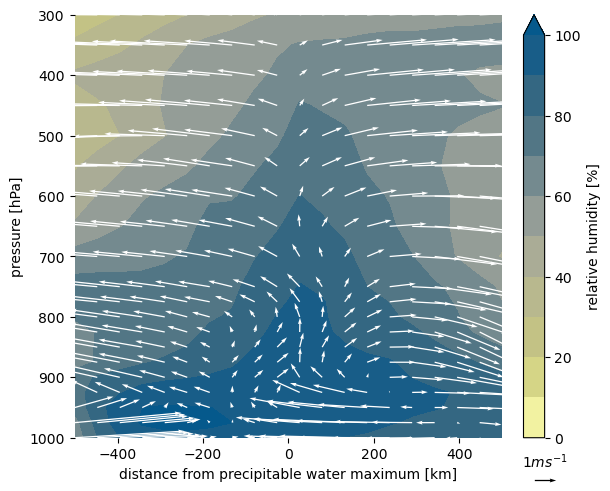

In [18]:
#plot cross-section of ERA5 composite anomaly relative humidity with wind vectors 

w, h = matplotlib.figure.figaspect(0.8)

fig,ax=plt.subplots(1,1,sharex=True,figsize=(w,h),constrained_layout=True)
cm1=ax.contourf(q_composite.distance,q_composite.plev/100,100*compute_rh(t_composite,q_composite,q_composite.plev),cmap=cmcr.nuuk_r,levels=np.linspace(0,100,11),extend='max')

up_anom=up_composite-up_composite.mean(dim='distance')

q=ax.quiver(up_composite.distance,up_composite.plev/100,up_anom,-2*w_composite,color='white',scale=20)

ax.quiverkey(q,1.1,-0.1,1,r'$1 ms^{-1}$',color='black')

ax.invert_yaxis()
ax.set_xlabel('distance from precipitable water maximum [km]')
ax.set_ylabel('pressure [hPa]')
cb=plt.colorbar(cm1)
cb.ax.set_ylabel('relative humidity [%]')
plt.savefig('/Users/fpithan/Documents/haloac3_paper/hac3_rhcirc_era5comp_f6c.pdf')

Text(0.5, 102.72222222222219, 'longitude relative to maximum moisture anomaly')

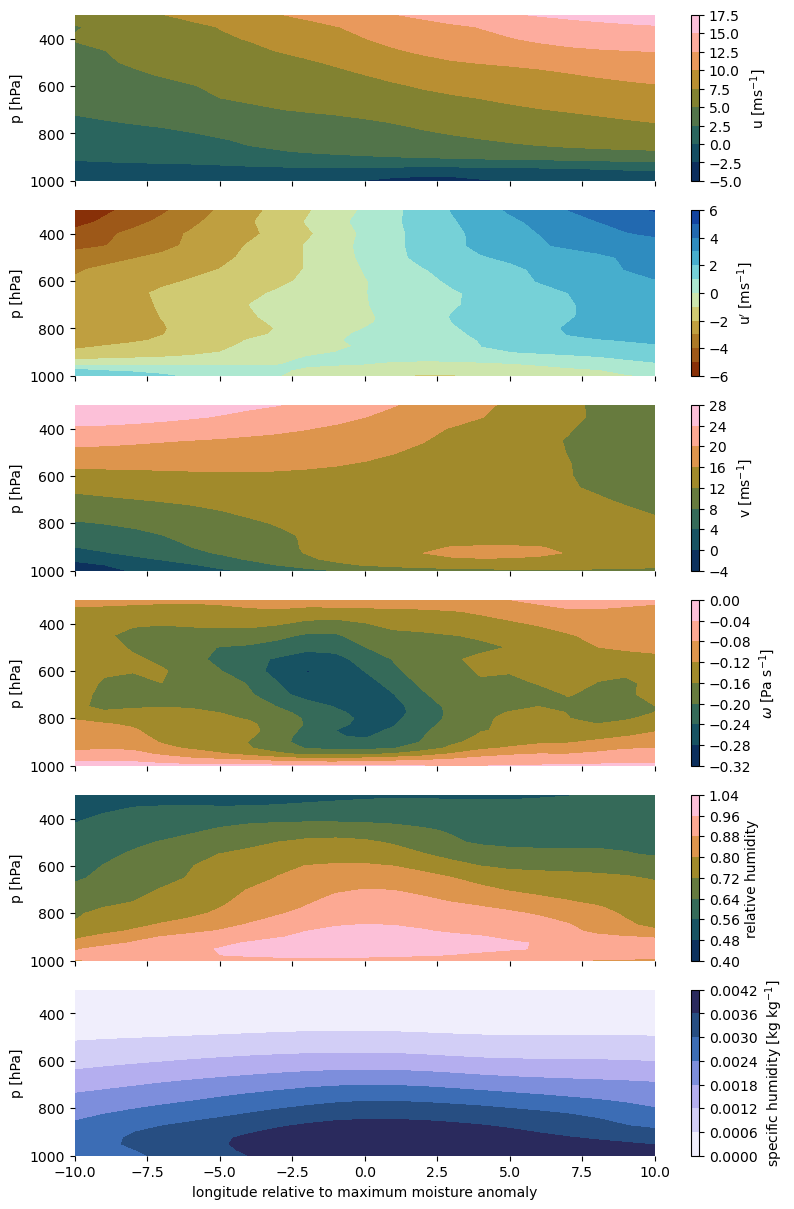

In [19]:
w, h = matplotlib.figure.figaspect(1.5)

fig,[ax1,ax2,ax3,ax4,ax5,ax6]=plt.subplots(6,1,sharex=True,figsize=(2*w,2*h))
cm1=ax1.contourf(zonal_wind_miref_a.lon,zonal_wind_miref_a.plev/100,zonal_wind_miref_a.mean('time',skipna=True),cmap=cmcr.batlow)
ax1.invert_yaxis()
cbar=plt.colorbar(cm1,ax=ax1)
cbar.ax.set_ylabel('u [ms$^{-1}$]')
cm2=ax2.contourf(zonal_wind_miref.lon,zonal_wind_miref.plev/100,zonal_wind_miref.mean('time',skipna=True),cmap=cmcr.roma,levels=10)
ax2.invert_yaxis()
cbar=plt.colorbar(cm2,ax=ax2)
cbar.ax.set_ylabel('u$\'$ [ms$^{-1}$]')
cm3=ax3.contourf(meridional_wind_miref.lon,meridional_wind_miref.plev/100,meridional_wind_miref.mean('time',skipna=True),cmap=cmcr.batlow)
ax3.invert_yaxis()
cbar=plt.colorbar(cm3,ax=ax3)
cbar.ax.set_ylabel('v [ms$^{-1}$]')
cm4=ax4.contourf(vertical_velocity_miref.lon,vertical_velocity_miref.plev/100,vertical_velocity_miref.mean('time',skipna=True),cmap=cmcr.batlow)
ax4.invert_yaxis()
cbar=plt.colorbar(cm4,ax=ax4)
cbar.ax.set_ylabel('$\omega$ [Pa s$^{-1}$]')

#cm5=ax5.contourf(zonal_wind_miref_a.lon,zonal_wind_miref_a.plev,((zonal_wind_miref_a**2+meridional_wind_miref**2)**0.5).mean('time',skipna=True),cmap=cmcr.batlow)
#ax5.invert_yaxis()
#cbar=plt.colorbar(cm5,ax=ax5)
#cbar.ax.set_ylabel('wind speed')


cm5=ax5.contourf(temp_miref.lon,zonal_wind_miref.plev/100,compute_rh(temp_miref,q_miref,temp_miref.plev).mean('time',skipna=True),cmap=cmcr.batlow)
ax5.invert_yaxis()
cbar=plt.colorbar(cm5,ax=ax5)
cbar.ax.set_ylabel('relative humidity')

cm6=ax6.contourf(q_miref.lon,q_miref.plev/100,q_miref.mean('time',skipna=True),cmap=cmcr.devon_r)
ax6.invert_yaxis()
cbar=plt.colorbar(cm6,ax=ax6)
cbar.ax.set_ylabel('specific humidity [kg kg$^{-1}$]')

fig.tight_layout()

ax1.set_xlim(-10,10)
ax1.set_ylabel('p [hPa]')
ax2.set_ylabel('p [hPa]')
ax3.set_ylabel('p [hPa]')
ax4.set_ylabel('p [hPa]')
ax5.set_ylabel('p [hPa]')
ax6.set_ylabel('p [hPa]')
ax6.set_xlabel('longitude relative to maximum moisture anomaly')


Assumed time difference in trajectories:   1.0 h
Maximum duration of trajectories:          24.0 h
Thus, each trajectory has                  24 entries

Overall, 152 trajectories are found
Header: ['TIME', 'LON', 'LAT', 'P']
Chosen variable name: TIME
Var_index found: var <TIME> found on col <0>
Header: ['TIME', 'LON', 'LAT', 'P']
Chosen variable name: P
Var_index found: var <P> found on col <3>


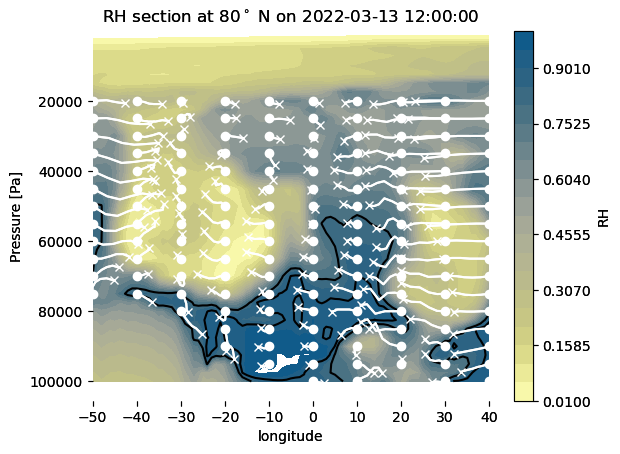

In [20]:



lstart=80

# get directory and set filename
directory = os.getcwd() + '/../data/'
fname="FS_20220313_12_"+str(lstart)+"N_profile_bw.1"
date_h="20220313_12"

# define which variables to plot
var_vec=['TIME', 'P']

#Helper function to only load specfic lines 
def generate_specific_rows(filePath, userows=[]):
    with open(filePath) as f:
        for i, line in enumerate(f):
            if i in userows:
                yield line

#header-line of .1 files is always line #2 (counting from 0)
header_line = [2]

# open the file
trajs = np.loadtxt(directory + fname, dtype="f", skiprows=5)

#-------------------------
#Process dataset
#-------------------------

#generate object to only load specific header line
gen = generate_specific_rows(directory + fname, userows=header_line) 
header = np.loadtxt(gen, dtype="str",unpack='true')
header=header.tolist() #convert to list
#convert to upper characters
for i in range(len(header)):
    header[i]=header[i].upper() #convert to upper

#Access some variables
times = trajs[:,0]
#lons  = trajs[:,1]
#lats  = trajs[:,2]

#get the time step of the trajectories
dt = abs(times[1]-times[0])
#maximum duration of a single trajectory
tmax = abs(max(times)) + abs(min(times))
#thus, a trajectory is composed of the following number of lines
traj_single_len = int(tmax/dt)                          #length of 1 traj
traj_overall_len = int(len(times))                      #total length of traj.1 file
traj_num = int(traj_overall_len/(traj_single_len+1))    #total number of trajs 
       
print("\nAssumed time difference in trajectories:   " + str(dt) + " h")
print("Maximum duration of trajectories:          " + str(tmax) + " h") 
print("Thus, each trajectory has                  " + str(traj_single_len) + " entries\n")
print("Overall, " + str(traj_num) + " trajectories are found")

#-------------------------
#Cycle over variables to plot
#-------------------------
for var_name in var_vec:
    print("Header: ", end="")
    print(header)
    print("Chosen variable name: " + var_name)

    #Now try to find first index of var in .1 file via try/expecpt block
    try:
        var_index=header.index(var_name.upper())
    except ValueError as e:
        print("\n\n>>>SKIPPING VAR<<< - not on file? Continue with next var...\n\n")
    else: 
        print("Var_index found: var <"+var_name+"> found on col <"+str(var_index)+">")

        # dictionary with plotting settings
        plt_sett = {
            'TIME':{
                'label'     :'time (h)',    
                'norm'      :plt.Normalize(-24,24),    
                'ylim'      :[-24,24],    
                'cmap_sel'  :'seismic',      
            },
            'P':{
                'label'     :'pressure (hPa)',    
                'norm'      :plt.Normalize(300, 1000),    
                'ylim'      :[250,1050],    
                'cmap_sel'  :'viridis',      
            },
        }




        axs = plt.axes()
       # m = 
        sellat=lstart

        ax=plt.subplot()
        cm=ax.contourf(f_q.lon,f_q.plev,f_q.var133.sel(time='2022-03-13 12:00:00',lat=sellat,method='nearest')/(0.622/(f_t.plev/100)*6.112*np.exp(17.62*(f_t.var130.sel(time='2022-03-13 12:00:00',lat=sellat,method='nearest')-273.15)/(243.12+f_t.var130.sel(time='2022-03-13 12:00:00',lat=sellat,method='nearest')-273.15))),levels=np.linspace(0.01,1,21),cmap=cmcr.nuuk_r)
        ax.contour(f_q.lon,f_q.plev,f_q.var133.sel(time='2022-03-13 12:00:00',lat=sellat,method='nearest')/(0.622/(f_t.plev/100)*6.112*np.exp(17.62*(f_t.var130.sel(time='2022-03-13 12:00:00',lat=sellat,method='nearest')-273.15)/(243.12+f_t.var130.sel(time='2022-03-13 12:00:00',lat=sellat,method='nearest')-273.15))),levels=np.linspace(0.8,0.9,2),colors='k')
        ax.invert_yaxis()
        ax.set_xlim(-50,40)
        ax.set_title('RH section at '+str(sellat)+'$^\circ$ N on '+'2022-03-13 12:00:00')
        ax.set_xlabel('longitude')
        ax.set_ylabel('Pressure [Pa]')

        cbar=plt.colorbar(cm,ax=ax)
        cbar.ax.set_ylabel('RH')
      
        # cycle over each trajectory individually to plot it
        for k in range(traj_num):
            # here, extract the lon, lat and variable arrays
            lons = trajs[k*(traj_single_len+1):(k+1)*(traj_single_len+1),1]
            lats = trajs[k*(traj_single_len+1):(k+1)*(traj_single_len+1),2]
            pres = trajs[k*(traj_single_len+1):(k+1)*(traj_single_len+1),3]
            var = trajs[k*(traj_single_len+1):(k+1)*(traj_single_len+1),var_index]
            # from here on, this is all connected to plotting
            ax.plot(lons[:6]*np.cos(lats[:6]*np.pi/180)/np.cos(sellat*np.pi/180),pres[:6]*100,color='white',linewidth=0.3)
            ax.plot(lons[:6]*np.cos(lats[:6]*np.pi/180)/np.cos(sellat*np.pi/180),pres[:6]*100,color='white',marker='x',markevery=[-1])
            ax.plot(lons[:6]*np.cos(lats[:6]*np.pi/180)/np.cos(sellat*np.pi/180),pres[:6]*100,color='white',marker='o',markevery=[0])
        



Assumed time difference in trajectories:   1.0 h
Maximum duration of trajectories:          24.0 h
Thus, each trajectory has                  24 entries

Overall, 149 trajectories are found
Pressure at start of trajectory: 200.0
Pressure at start of trajectory: 200.0
Pressure at start of trajectory: 200.0
Pressure at start of trajectory: 200.0
Pressure at start of trajectory: 200.0
Pressure at start of trajectory: 200.0
Pressure at start of trajectory: 250.0
Pressure at start of trajectory: 250.0
Pressure at start of trajectory: 250.0
Pressure at start of trajectory: 250.0
Pressure at start of trajectory: 250.0
Pressure at start of trajectory: 250.0
Pressure at start of trajectory: 300.0
Pressure at start of trajectory: 300.0
Pressure at start of trajectory: 300.0
Pressure at start of trajectory: 300.0
Pressure at start of trajectory: 300.0
Pressure at start of trajectory: 300.0
Pressure at start of trajectory: 350.0
Pressure at start of trajectory: 350.0
Pressure at start of trajecto

/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/fpithan/.local/share/mamba/envs/metenv2/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/fpithan/.local/share/mamba/envs/m

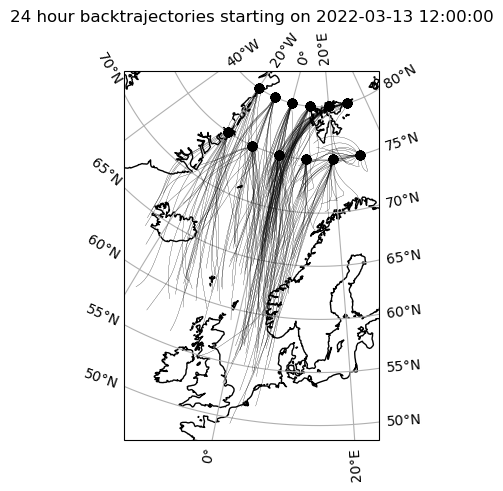

In [21]:
# plot map of backtrajectories

trajs={}
traj_single_len={}
traj_num={}

w,h=plt.figaspect(1)
fig=plt.figure(figsize=(w,h),constrained_layout=True)

handles=[]

#define map of Fram strait
ax = plt.axes(projection=ccrs.TransverseMercator(central_longitude=15.0, central_latitude=75.0, false_easting=0.0, false_northing=0.0, scale_factor=1.0, globe=None, approx=None))
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.coastlines()

ax.set_title('24 hour backtrajectories starting on '+'2022-03-13 12:00:00')

for lstart in [75,80]:
   
    # get directory and set filename
    directory = os.getcwd() + '/../data/'
    fname="FS_20220313_12_"+str(lstart)+"N_profile_bw.1"
    date_h="20220313_12"

    # define which variables to plot
    var_vec=['TIME', 'P']

    #Helper function to only load specfic lines 
    def generate_specific_rows(filePath, userows=[]):
        with open(filePath) as f:
            for i, line in enumerate(f):
                if i in userows:
                    yield line

    #header-line of .1 files is always line #2 (counting from 0)
    header_line = [2]

    # open the file
    trajs[str(lstart)] = np.loadtxt(directory + fname, dtype="f", skiprows=5)

    #-------------------------
    #Process dataset
    #-------------------------

    #generate object to only load specific header line
    gen = generate_specific_rows(directory + fname, userows=header_line) 
    header = np.loadtxt(gen, dtype="str",unpack='true')
    header=header.tolist() #convert to list
    #convert to upper characters
    for i in range(len(header)):
        header[i]=header[i].upper() #convert to upper

    #Access some variables
    times = trajs[str(lstart)][:,0]
    #lons  = trajs[:,1]
    #lats  = trajs[:,2]

    #get the time step of the trajectories
    dt = abs(times[1]-times[0])
    #maximum duration of a single trajectory
    tmax = abs(max(times)) + abs(min(times))
    #thus, a trajectory is composed of the following number of lines
    traj_single_len[str(lstart)] = int(tmax/dt)                          #length of 1 traj
    traj_overall_len = int(len(times))                      #total length of traj.1 file
    traj_num[str(lstart)] = int(traj_overall_len/(traj_single_len[str(lstart)]+1))    #total number of trajs 
        
    print("\nAssumed time difference in trajectories:   " + str(dt) + " h")
    print("Maximum duration of trajectories:          " + str(tmax) + " h") 
    print("Thus, each trajectory has                  " + str(traj_single_len[str(lstart)]) + " entries\n")
    print("Overall, " + str(traj_num[str(lstart)]) + " trajectories are found")

     # cycle over each trajectory individually to plot it
    for k in range(traj_num[str(lstart)]):
        # here, extract the lon, lat and variable arrays
        lons = trajs[str(lstart)][k*(traj_single_len[str(lstart)]+1):(k+1)*(traj_single_len[str(lstart)]+1),1]
        lats = trajs[str(lstart)][k*(traj_single_len[str(lstart)]+1):(k+1)*(traj_single_len[str(lstart)]+1),2]
        pres = trajs[str(lstart)][k*(traj_single_len[str(lstart)]+1):(k+1)*(traj_single_len[str(lstart)]+1),3]
        var = trajs[str(lstart)][k*(traj_single_len[str(lstart)]+1):(k+1)*(traj_single_len[str(lstart)]+1),var_index]

        if(lons[0]<-20) or (lons[0]>30) or (pres[0]<200): 
            continue
        # from here on, this is all connected to plotting
        print("Pressure at start of trajectory: " + str(pres[0]))
        ax.plot(lons,lats,color='k',linewidth=0.1,transform=ccrs.PlateCarree())
       #ax.plot(lons,lats,color='k',linewidth=0.1,marker='x',markevery=[-1],transform=ccrs.PlateCarree())
        ax.plot(lons,lats,color='k',linewidth=0.1,marker='o',markevery=[0],transform=ccrs.PlateCarree())

plt.savefig('/Users/fpithan/Documents/haloac3_paper/hac3_trajectories_SI.pdf')

R^2 of start vs. end RH for 75$^\circ$N trajectories: 0.3634606210698004
R^2 of start vs. end RH for 80$^\circ$N trajectories: 0.13469972107523687


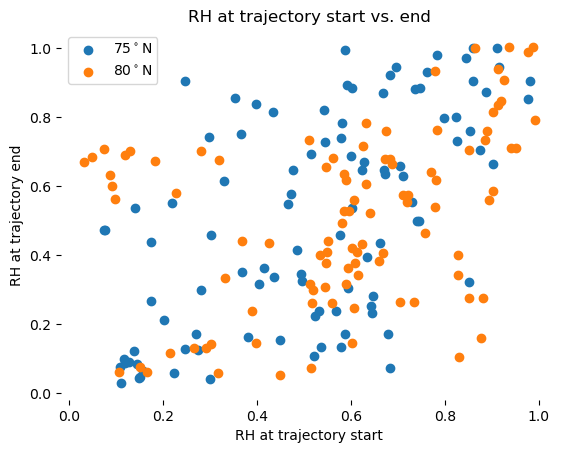

In [22]:
#compute r^2 of start vs. end RH for trajectories starting at 80 and 75 N

for lstart,traj in trajs.items(): 

    # starting point of trajectories 
    starttime='2022-03-13 12:00:00'
    endtime='2022-03-12 12:00:00'
    startlon=[]
    startlat=[]
    startpres=[]
    startrh=[]

    endlon=[]
    endlat=[]
    endpres=[]
    endrh=[]
    minpres=[]
    maxpres=[]

    for k in range(traj_num[str(lstart)]):
        # here, extract the lon, lat and variable arrays
        lons = traj[k*(traj_single_len[lstart]+1):(k+1)*(traj_single_len[lstart]+1),1]
        lats = traj[k*(traj_single_len[lstart]+1):(k+1)*(traj_single_len[lstart]+1),2]
        pres = traj[k*(traj_single_len[lstart]+1):(k+1)*(traj_single_len[lstart]+1),3]

        if(lons[0]<-20) or (lons[0]>30) or (pres[0]<200): 
            continue
        
        
        
        start_rh=extract_rh(starttime,lats[0],lons[0],pres[0]*100)
        startlon.append(lons[0])
        startlat.append(lats[0])
        startpres.append(pres[0])
        startrh.append(np.squeeze(start_rh.values))

        #plt.plot(lats,pres[0]-pres,color=cmcr.nuuk_r(start_rh.values.item()))

        #plt.gca().set_ylim(-100,100)
        
        minpres.append(min(pres))
        maxpres.append(max(pres))

        end_rh=extract_rh(endtime,lats[-1],lons[-1],pres[-1]*100)
        endlon.append(lons[-1])
        endlat.append(lats[-1])
        endpres.append(pres[-1])
        endrh.append(np.squeeze(end_rh.values))

    np.corrcoef(startrh,endrh)
    print("R^2 of start vs. end RH for "+str(lstart)+"$^\circ$N trajectories: ", end="")
    print(np.corrcoef(startrh,endrh)[0,1]**2)

    plt.scatter(startrh,endrh)
plt.gca().set_xlabel('RH at trajectory start')
plt.gca().set_ylabel('RH at trajectory end')
plt.gca().set_title('RH at trajectory start vs. end')

plt.legend(['75$^\circ$N','80$^\circ$N'])
plt.savefig('/Users/fpithan/Documents/haloac3_paper/traj_rh_start_end.pdf')

